# Instalar

In [1]:
!pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 4.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/1

In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.5/100.5 kB 5.8 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np

In [2]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/TFM/csv/datos_preprocesados.csv')
df.columns

Index(['address', 'agency_name', 'bathroom_count', 'bedroom_count',
       'energy_certificate', 'floor', 'latitude', 'longitude', 'lot_size',
       'property_description', 'property_id', 'property_images',
       'property_price', 'property_title', 'property_type', 'neighborhood',
       'exterior', 'ascensor'],
      dtype='object')

In [ ]:
# Ruta Laura

df = pd.read_csv('/content/drive/MyDrive/TFM/csv/datos_preprocesados.csv')

image_folder_path = '/content/drive/MyDrive/TFM/fotos'

In [ ]:
# Ruta Alvaro
df = pd.read_csv('/content/drive/MyDrive/tfm/TFM/datos_limpio.csv')

image_folder_path = '/content/drive/MyDrive/tfm/TFM/fotos_10'

In [ ]:
# Ruta Ángel

df = pd.read_csv('/content/drive/MyDrive/CEU SAN PABLO/TFM/datos.csv')

image_folder_path = '/content/drive/MyDrive/CEU SAN PABLO/TFM/fotos'

# 1. Altura piso

## 1.1 Funciones

In [ ]:
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import os
import warnings
import torch
import torchvision.transforms as T
import numpy as np
warnings.filterwarnings('ignore')

In [ ]:
# Funciones para calcular altura
class SimpleCeilingHeightEstimator:
    def __init__(self):
        # Rangos típicos de altura de techo en Madrid
        self.height_ranges = {
            'low': (2.3, 2.6),      # Pisos modernos/reformados
            'medium': (2.6, 3.0),   # Estándar
            'high': (3.0, 3.8),     # Edificios clásicos con techos altos
            'very_high': (3.8, 4.5) # Edificios señoriales
        }

    def analyze_image_characteristics(self, image):
        """Analiza características visuales básicas de la imagen"""
        height, width, _ = image.shape

        # Convertir a escala de grises para análisis
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        # 1. RATIO DE ASPECTO DE LA IMAGEN
        aspect_ratio = height / width

        # 2. DETECTAR LÍNEAS VERTICALES PROMINENTES (esquinas, marcos)
        edges = cv2.Canny(gray, 50, 150, apertureSize=3)
        lines = cv2.HoughLines(edges, 1, np.pi/180, threshold=int(height*0.3))

        vertical_lines = 0
        if lines is not None:
            for line in lines:
                _, theta = line[0]
                # Contar líneas verticales
                if abs(theta) < 0.3 or abs(theta - np.pi) < 0.3:
                    vertical_lines += 1

        # 3. ANALIZAR DISTRIBUCIÓN DE INTENSIDAD VERTICAL
        # Dividir imagen en franjas horizontales
        strip_height = height // 10
        brightness_profile = []

        for i in range(10):
            start_y = i * strip_height
            end_y = min((i + 1) * strip_height, height)
            strip = gray[start_y:end_y, :]
            avg_brightness = np.mean(strip)
            brightness_profile.append(avg_brightness)

        # 4. DETECTAR CARACTERÍSTICAS ARQUITECTÓNICAS
        # Buscar patrones que indiquen techos altos vs bajos

        # Variación de brillo en la parte superior (posible techo decorativo)
        upper_variation = np.std(brightness_profile[:3])

        # Contraste general de la imagen
        overall_contrast = np.std(gray)

        # Presencia de elementos en la parte superior de la imagen
        upper_third = gray[:height//3, :]
        upper_edges = cv2.Canny(upper_third, 50, 150)
        upper_edge_density = np.sum(upper_edges > 0) / upper_third.size

        return {
            'aspect_ratio': aspect_ratio,
            'vertical_lines': vertical_lines,
            'brightness_profile': brightness_profile,
            'upper_variation': upper_variation,
            'overall_contrast': overall_contrast,
            'upper_edge_density': upper_edge_density,
            'image_height': height,
            'image_width': width
        }

    def classify_ceiling_type(self, characteristics):
        """Clasifica el tipo de techo basándose en características visuales"""

        # Inicializar puntuaciones para cada tipo
        scores = {
            'low': 0,
            'medium': 0,
            'high': 0,
            'very_high': 0
        }

        # FACTOR 1: Ratio de aspecto de la imagen
        aspect_ratio = characteristics['aspect_ratio']
        if aspect_ratio < 0.6:  # Imagen muy ancha = vista panorámica = techo bajo
            scores['low'] += 2
            scores['medium'] += 1
        elif aspect_ratio < 0.8:  # Imagen moderadamente ancha
            scores['medium'] += 2
            scores['low'] += 1
        elif aspect_ratio < 1.2:  # Imagen cuadrada
            scores['medium'] += 2
            scores['high'] += 1
        else:  # Imagen alta = posible techo alto
            scores['high'] += 2
            scores['very_high'] += 1
            if aspect_ratio > 1.5:
                scores['very_high'] += 1

        # FACTOR 2: Líneas verticales (elementos arquitectónicos)
        vertical_lines = characteristics['vertical_lines']
        if vertical_lines > 8:  # Muchas líneas = arquitectura compleja = techo alto
            scores['high'] += 2
            scores['very_high'] += 1
        elif vertical_lines > 4:
            scores['medium'] += 1
            scores['high'] += 1
        else:
            scores['low'] += 1
            scores['medium'] += 1

        # FACTOR 3: Variación en la parte superior (molduras, decoración)
        upper_variation = characteristics['upper_variation']
        if upper_variation > 30:  # Mucha variación = decoración = techo alto
            scores['high'] += 2
            scores['very_high'] += 1
        elif upper_variation > 15:
            scores['medium'] += 1
            scores['high'] += 1
        else:
            scores['low'] += 1
            scores['medium'] += 1

        # FACTOR 4: Densidad de bordes en parte superior
        upper_edge_density = characteristics['upper_edge_density']
        if upper_edge_density > 0.1:  # Muchos detalles arriba = techo decorado
            scores['high'] += 1
            scores['very_high'] += 1
        elif upper_edge_density > 0.05:
            scores['medium'] += 1
        else:
            scores['low'] += 1

        # FACTOR 5: Contraste general
        overall_contrast = characteristics['overall_contrast']
        if overall_contrast > 60:  # Alto contraste = espacios amplios = techos altos
            scores['high'] += 1
            scores['very_high'] += 1
        elif overall_contrast > 40:
            scores['medium'] += 1
        else:
            scores['low'] += 1

        # Encontrar la categoría con mayor puntuación
        best_category = max(scores.keys(), key=lambda k: scores[k])
        confidence = scores[best_category] / sum(scores.values())

        return best_category, confidence, scores

    def estimate_height_from_category(self, category, confidence):
        """Convierte la categoría en una altura específica"""
        range_min, range_max = self.height_ranges[category]

        # Usar un valor dentro del rango, ajustado por confianza
        if confidence > 0.7:
            # Alta confianza: usar valor medio del rango
            height = (range_min + range_max) / 2
        elif confidence > 0.5:
            # Confianza media: tender hacia el centro general (2.7m)
            height = (range_min + range_max) / 2
            height = height * 0.7 + 2.7 * 0.3  # Mezclar con valor conservador
        else:
            # Baja confianza: usar valor conservador
            height = 2.7

        # Añadir pequeña variación aleatoria para evitar valores idénticos
        height += np.random.normal(0, 0.05)  # ±5cm de variación

        return max(2.2, min(4.5, height))  # Limitar entre 2.2 y 4.5m

    def analyze_single_image(self, image_path):
        """Analiza una sola imagen"""
        try:
            # Cargar imagen
            if isinstance(image_path, str):
                image = cv2.imread(image_path)
                if image is None:
                    raise ValueError(f"No se pudo cargar la imagen: {image_path}")
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            else:
                image = image_path

            # Analizar características
            characteristics = self.analyze_image_characteristics(image)

            # Clasificar tipo de techo
            category, confidence, scores = self.classify_ceiling_type(characteristics)

            # Estimar altura
            estimated_height = self.estimate_height_from_category(category, confidence)

            return {
                'estimated_height': round(estimated_height, 2),
                'category': category,
                'confidence': round(confidence, 2),
                'scores': scores,
                'characteristics': characteristics
            }

        except Exception as e:
            print(f"Error analizando imagen {image_path}: {e}")
            return {
                'estimated_height': 2.7,  # Valor por defecto
                'category': 'medium',
                'confidence': 0.2,
                'error': str(e)
            }

    def analyze_property_images(self, image_folder, property_id):
        """Analiza todas las imágenes de una propiedad"""
        try:
            # Buscar imágenes de la propiedad
            all_files = os.listdir(image_folder)
            property_files = [f for f in all_files if f.startswith(f'foto_{property_id}_') and f.lower().endswith('.webp')]

            if not property_files:
                return {
                    'property_id': property_id,
                    'estimated_height': 2.7,
                    'confidence': 0.2,
                    'images_analyzed': 0,
                    'method': 'no_images_found'
                }

            # Analizar cada imagen
            results = []
            for filename in property_files:
                image_path = os.path.join(image_folder, filename)
                result = self.analyze_single_image(image_path)
                result['filename'] = filename
                results.append(result)

            # Combinar resultados
            valid_results = [r for r in results if 'error' not in r]

            if not valid_results:
                return {
                    'property_id': property_id,
                    'estimated_height': 2.7,
                    'confidence': 0.2,
                    'images_analyzed': len(results),
                    'method': 'all_errors'
                }

            # Calcular estadísticas
            heights = [r['estimated_height'] for r in valid_results]
            confidences = [r['confidence'] for r in valid_results]
            categories = [r['category'] for r in valid_results]

            # Altura final: mediana (más robusta que media)
            final_height = np.median(heights)

            # Confianza final: promedio ponderado
            final_confidence = np.mean(confidences)

            # Ajustar confianza según consistencia
            height_std = np.std(heights)
            if height_std < 0.2:  # Muy consistente
                final_confidence = min(0.9, final_confidence + 0.2)
            elif height_std < 0.4:  # Razonablemente consistente
                final_confidence = final_confidence
            else:  # Inconsistente
                final_confidence = max(0.3, final_confidence - 0.2)

            # Categoría más común
            most_common_category = max(set(categories), key=categories.count)

            return {
                'property_id': property_id,
                'estimated_height': round(final_height, 2),
                'confidence': round(final_confidence, 2),
                'images_analyzed': len(valid_results),
                'height_std': round(height_std, 2),
                'most_common_category': most_common_category,
                'method': 'multi_image_median',
                'individual_results': results
            }

        except Exception as e:
            print(f"Error procesando propiedad {property_id}: {e}")
            return {
                'property_id': property_id,
                'estimated_height': 2.7,
                'confidence': 0.2,
                'images_analyzed': 0,
                'method': 'error',
                'error': str(e)
            }

In [ ]:
def estimate_ceiling_heights_batch(image_folder_path, output_file='ceiling_heights.csv', max_properties=None):
    """Procesa todas las propiedades y genera CSV"""
    estimator = SimpleCeilingHeightEstimator()

    # Obtener IDs únicos de propiedades
    all_files = os.listdir(image_folder_path)
    property_ids = set()

    for filename in all_files:
        if filename.startswith('foto_') and filename.endswith('.webp'):
            try:
                parts = filename.split('_')
                if len(parts) >= 2:
                    property_id = parts[1]
                    property_ids.add(property_id)
            except:
                continue

    property_ids = sorted(list(property_ids))
    if max_properties:
        property_ids = property_ids[:max_properties]

    print(f"Procesando {len(property_ids)} propiedades...")

    # Procesar cada propiedad
    results = []
    for i, prop_id in enumerate(property_ids):
        if (i + 1) % 50 == 0:
            print(f"Procesadas {i+1}/{len(property_ids)} propiedades...")

        result = estimator.analyze_property_images(image_folder_path, prop_id)
        results.append(result)

    # Crear DataFrame
    import pandas as pd

    df_results = pd.DataFrame([{
        'property_id': r['property_id'],
        'estimated_height_m': r['estimated_height'],
        'confidence': r['confidence'],
        'images_count': r['images_analyzed'],
        'height_std': r.get('height_std', 0),
        'category': r.get('most_common_category', 'unknown'),
        'method': r['method']
    } for r in results])

    # Guardar
    df_results.to_csv(output_file, index=False)
    print(f"\nResultados guardados en {output_file}")

    # Estadísticas
    valid_results = df_results[df_results['images_count'] > 0]
    print(f"\nEstadísticas ({len(valid_results)} propiedades válidas):")
    print(f"Altura media: {valid_results['estimated_height_m'].mean():.2f}m")
    print(f"Desviación estándar: {valid_results['estimated_height_m'].std():.2f}m")
    print(f"Rango: {valid_results['estimated_height_m'].min():.2f}m - {valid_results['estimated_height_m'].max():.2f}m")
    print(f"Confianza promedio: {valid_results['confidence'].mean():.2f}")

    # Distribución por categorías
    print(f"\nDistribución por categorías:")
    for category in valid_results['category'].value_counts().index:
        count = valid_results['category'].value_counts()[category]
        avg_height = valid_results[valid_results['category'] == category]['estimated_height_m'].mean()
        print(f"  {category}: {count} propiedades (altura media: {avg_height:.2f}m)")

    return df_results, results


## 1.2 pruebas de una sola propiedad

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

def mostrar_imagenes(df, image_folder_path, max_imgs=4):
    # Obtener el property_id de la primera fila
    property_id = str(df.loc[df.index[0], 'property_id'])

    print(f"Intentando abrir hasta {max_imgs} imágenes para property_id {property_id}...")

    imagenes_mostradas = 0
    i = 1  # Índice de la imagen

    while imagenes_mostradas < max_imgs:
        filename = f"foto_{property_id}_{i}.webp"
        image_path = os.path.join(image_folder_path, filename)

        if os.path.exists(image_path):
            try:
                img = Image.open(image_path)
                plt.imshow(img)
                plt.title(filename)
                plt.axis('off')
                plt.show()
                imagenes_mostradas += 1
            except Exception as e:
                print(f"No se pudo abrir la imagen {filename}: {e}")
        else:
            # Si el archivo no existe, asumimos que ya no hay más imágenes numeradas
            break

        i += 1

    if imagenes_mostradas == 0:
        print("No se encontró ninguna imagen para este property_id.")


Intentando abrir hasta 4 imágenes para property_id 106763707...


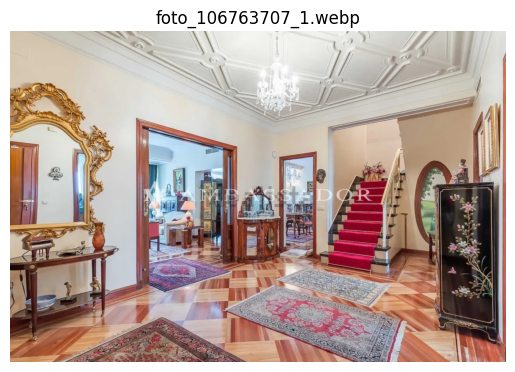

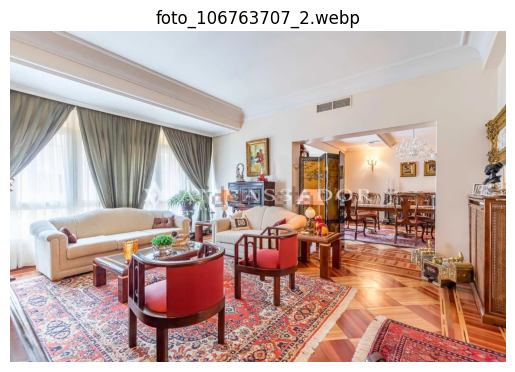

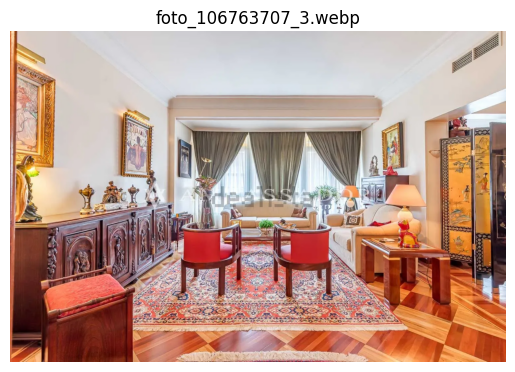

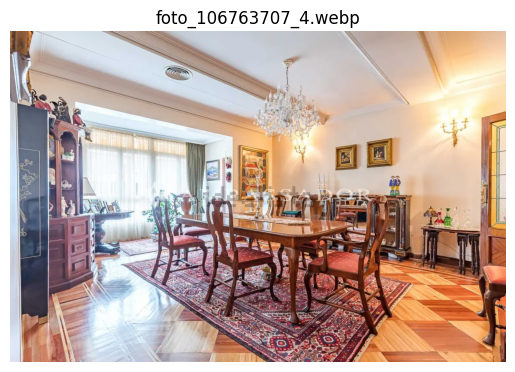

In [ ]:
mostrar_imagenes(df,image_folder_path)


#### Pruebas con midas

In [ ]:
# Cargar el modelo MiDaS
midas = torch.hub.load("intel-isl/MiDaS", "DPT_Large")
midas.to("cuda" if torch.cuda.is_available() else "cpu").eval()

# Transformaciones necesarias
transform = T.Compose([
    T.Resize((384, 384)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v3/dpt_large_384.pt" to /root/.cache/torch/hub/checkpoints/dpt_large_384.pt
100%|██████████| 1.28G/1.28G [00:18<00:00, 74.0MB/s]


In [ ]:
def estimate_height(image_path):
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        prediction = midas(input_tensor)
        prediction = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=img.size[::-1],
            mode="bicubic",
            align_corners=False,
        ).squeeze()

    depth_map = prediction.cpu().numpy()

    # Mostrar imagen + profundidad
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Imagen original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(depth_map, cmap="inferno")
    plt.title("Mapa de profundidad")
    plt.axis("off")
    plt.show()

    # Heurística de altura relativa suelo-techo (en proporción, no en metros)
    techo = np.percentile(depth_map[:depth_map.shape[0]//5, :], 90)
    suelo = np.percentile(depth_map[-depth_map.shape[0]//5:, :], 10)
    diff = abs(suelo - techo)

    if diff < 0.1:
        return "No aplicable (posible terraza o sin suelo/techo visible)"
    else:
        altura_relativa = diff / depth_map.max()  # valor entre 0 y 1
        return f"Altura detectable (relativa): {altura_relativa:.2f}"

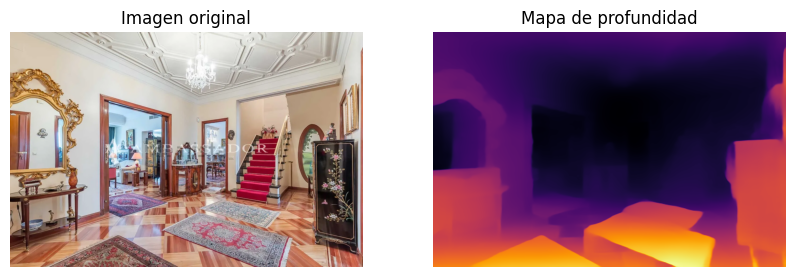

foto_106763707_1.webp ➜ Altura detectable (relativa): 0.16


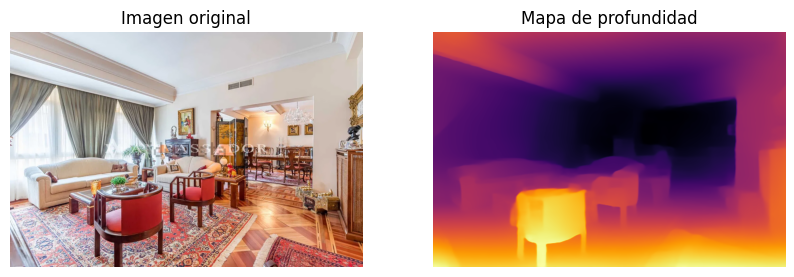

foto_106763707_2.webp ➜ Altura detectable (relativa): 0.06


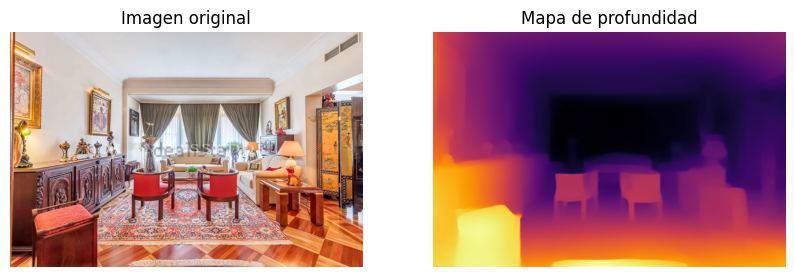

foto_106763707_3.webp ➜ Altura detectable (relativa): 0.06


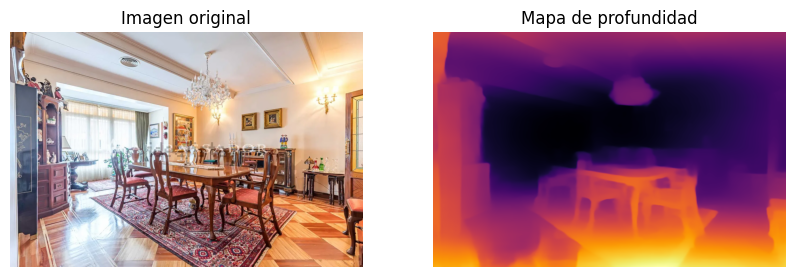

foto_106763707_4.webp ➜ Altura detectable (relativa): 0.05


In [ ]:
property_id = str(df.loc[0, 'property_id'])
for i in range(1, 5):
    filename = f"foto_{property_id}_{i}.webp"
    image_path = os.path.join(image_folder_path, filename)
    if os.path.exists(image_path):
        resultado = estimate_height(image_path)
        print(f"{filename} ➜ {resultado}")



#### Pruebas con nuestra clase

In [ ]:
def test_single_property(image_folder_path, property_id):
    """Prueba el algoritmo con una propiedad específica"""
    estimator = SimpleCeilingHeightEstimator()
    result = estimator.analyze_property_images(image_folder_path, property_id)

    print(f"\n=== RESULTADO PARA PROPIEDAD {property_id} ===")
    print(f"Altura estimada: {result['estimated_height']}m")
    print(f"Categoría: {result.get('most_common_category', 'N/A')}")
    print(f"Confianza: {result['confidence']:.2f}")
    print(f"Imágenes analizadas: {result['images_analyzed']}")
    print(f"Desviación entre imágenes: {result.get('height_std', 0):.2f}m")
    print(f"Método: {result['method']}")

    # Mostrar detalles de cada imagen si están disponibles
    if 'individual_results' in result:
        print(f"\nDetalle por imagen:")
        for img_result in result['individual_results']:
            if 'error' not in img_result:
                print(f"  {img_result['filename']}: {img_result['estimated_height']}m "
                      f"({img_result['category']}, conf: {img_result['confidence']:.2f})")

    return result

In [ ]:
# ID de la propiedad que queremos analizar (basado en los nombres de archivo 'foto_1231_...')
property_id_to_test = str(df.loc[0, 'property_id'])

# Crear una instancia de la clase SimpleCeilingHeightEstimator
estimator = SimpleCeilingHeightEstimator()

# Llamar a la función analyze_property_images para esta propiedad específica
# Esta función ya maneja la búsqueda de todas las fotos con ese ID en la carpeta
result = estimator.analyze_property_images(image_folder_path, property_id_to_test)

# Imprimir el resultado del análisis para esta propiedad
print(f"\nResultado del análisis de altura para la propiedad {property_id_to_test}:")
print(f"Altura estimada: {result['estimated_height']}m")
print(f"Confianza: {result['confidence']:.2f}")
print(f"Imágenes analizadas: {result['images_analyzed']}")
print(f"Desviación estándar entre imágenes: {result.get('height_std', 0):.2f}m")
print(f"Método principal: {result['method']}")
print(f"Categoría de techo más común: {result.get('most_common_category', 'N/A')}")



Resultado del análisis de altura para la propiedad 106763707:
Altura estimada: 2.68m
Confianza: 0.72
Imágenes analizadas: 10
Desviación estándar entre imágenes: 0.08m
Método principal: multi_image_median
Categoría de techo más común: medium


## 1.3 Automatización

In [ ]:
# 1. Función para procesar todas las propiedades y asignar alturas al DataFrame
def asignar_alturas_techos(df, image_folder_path):
    # Crear el estimador
    estimator = SimpleCeilingHeightEstimator()

    # Lista para guardar alturas en el mismo orden que el DataFrame
    alturas_techos = []

    print(f"Procesando {len(df)} propiedades...")

    for idx in df.index:
        # Obtener el property_id de la fila actual
        property_id = df.loc[idx, 'property_id']

        # Obtener todas las imágenes para este property_id
        image_files = [f for f in os.listdir(image_folder_path)
                      if f.startswith(f'foto_{property_id}_') and f.endswith('.webp')]

        if not image_files:
            print(f"Advertencia: No hay imágenes para property_id {property_id}. Usando valor por defecto (2.7m).")
            alturas_techos.append(2.7)
            continue

        # Procesar imágenes de esta propiedad
        resultados_imagenes = []
        for img_file in image_files:
            img_path = os.path.join(image_folder_path, img_file)
            try:
                result = estimator.analyze_single_image(img_path)
                resultados_imagenes.append(result['estimated_height'])
            except Exception as e:
                print(f"Error procesando {img_file}: {str(e)}")

        if resultados_imagenes:
            # Usar la MEDIANA de las alturas estimadas (robusta a outliers)
            altura_final = np.median(resultados_imagenes)
            alturas_techos.append(altura_final)
        else:
            alturas_techos.append(2.7)  # Valor por defecto si falla todo

    # Añadir la columna sin modificar el resto del DataFrame
    df = df.copy()
    df['altura_techo'] = alturas_techos

    return df

In [ ]:
df_techos = asignar_alturas_techos(df, image_folder_path)

In [ ]:
df_techos.to_csv('/content/drive/MyDrive/TFM/csv/datos_imagenes.csv', index=False)
print("\nDataset actualizado guardado correctamente.")

# 2. Tipo de suelo


In [ ]:
!pip install inference_sdk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.11.0.86
    Uninstalling opencv-python-4.11.0.86:
      Successfully uninstalled opencv-python-4.11.0.86
  Attempting uninstall: aiohttp
    Found existing installation: aiohttp 3.11.15
    Uninstalling aiohttp-3.11.15:
      Successfully uninstalled aiohttp-3.11.15


In [ ]:
from collections import Counter
from inference_sdk import InferenceHTTPClient

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/TFM/csv/datos_imagenes.csv')
df.columns

Index(['address', 'agency_name', 'bathroom_count', 'bedroom_count',
       'energy_certificate', 'floor', 'latitude', 'longitude', 'lot_size',
       'property_description', 'property_id', 'property_images',
       'property_price', 'property_title', 'property_type', 'neighborhood',
       'exterior', 'ascensor', 'altura_techo'],
      dtype='object')

In [ ]:
def asignar_tipo_suelo(df, image_folder_path):
    # Crear el cliente de Roboflow
    CLIENT = InferenceHTTPClient(
        api_url="https://serverless.roboflow.com",
        api_key="rGadRN7LvFBeMd77vruM"
    )

    tipos_suelo = []

    print(f"Procesando tipo de suelo para {len(df)} propiedades...")

    for idx in df.index:
        # Obtener el property_id de la fila actual
        property_id = df.loc[idx, 'property_id']

        # Buscar las imágenes para este property_id
        image_files = sorted([
            f for f in os.listdir(image_folder_path)
            if f.startswith(f'foto_{property_id}_') and f.endswith('.webp')
        ])

        if not image_files:
            print(f"Advertencia: No hay imágenes para property_id {property_id}. Tipo de suelo marcado como 'desconocido'.")
            tipos_suelo.append('desconocido')
            continue

        predicciones = []
        anterior = None
        repeticiones = 0

        for i, image_file in enumerate(image_files[:3]):  # Limitar a máximo 3 imágenes
            img_path = os.path.join(image_folder_path, image_file)
            try:
                result = CLIENT.infer(img_path, model_id="floor-types/2")
                prediction = result['predictions'][0]['class'] if result['predictions'] else 'sin_predicción'
                predicciones.append(prediction)

                # Checar si hay 2 predicciones iguales consecutivas
                if prediction == anterior:
                    repeticiones += 1
                else:
                    repeticiones = 1
                    anterior = prediction

                if repeticiones == 2:
                    # Ya tenemos 2 iguales consecutivas, suficiente
                    break
            except Exception as e:
                print(f"Error procesando {img_path}: {str(e)}")
                predicciones.append('error')

        # Contar la clase más frecuente (evita errores si hay múltiples diferentes)
        if predicciones:
            clase_predominante = Counter(predicciones).most_common(1)[0][0]
            tipos_suelo.append(clase_predominante)
        else:
            tipos_suelo.append('sin_predicción')

    df = df.copy()
    df['tipo_suelo'] = tipos_suelo

    return df

In [ ]:
df_suelos = asignar_tipo_suelo(df, image_folder_path)

Procesando tipo de suelo para 1159 propiedades...


In [ ]:
df_suelos.to_csv('/content/drive/MyDrive/TFM/csv/datos_imagenes.csv', index=False)

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/TFM/csv/datos_imagenes.csv')

In [ ]:
df_final = df
#df_final['property_type_chalet'] = df_final['property_type_chalet'].fillna(False)

In [ ]:
df_final.to_csv('/content/drive/MyDrive/TFM/csv/datos_imagenes.csv', index=False)

# 3 Estilo arquitectónico

In [ ]:
import os
import torch
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import numpy as np
from collections import Counter
import torch.nn as nn

def asignar_estilo_arquitectonico(df, image_folder_path, modelo_path, label_map):
    # 1. Cargar modelo
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = models.resnet50()
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, len(label_map))
    )

    model.load_state_dict(torch.load(modelo_path, map_location=device))
    model = model.to(device)
    model.eval()

    # 2. Transformaciones (deben coincidir con las del entrenamiento)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    idx2label = {v: k for k, v in label_map.items()}

    estilos_predichos = []

    print(f"Procesando {len(df)} propiedades...")

    for idx in df.index:
        # Obtener el property_id de la fila actual
        property_id = df.loc[idx, 'property_id']

        # Buscar las imágenes para este property_id
        image_files = [f for f in os.listdir(image_folder_path)
                       if f.startswith(f'foto_{property_id}_') and f.endswith('.webp')]

        predicciones = []
        for img_file in image_files:
            img_path = os.path.join(image_folder_path, img_file)
            try:
                image = Image.open(img_path).convert('RGB')
                image = transform(image).unsqueeze(0).to(device)

                with torch.no_grad():
                    output = model(image)
                    pred = torch.argmax(output, dim=1).item()
                    pred_label = idx2label[pred]
                    predicciones.append(pred_label)
            except Exception as e:
                print(f"Error procesando {img_file}: {str(e)}")

        if predicciones:
            # Tomar la moda de estilos predichos por piso
            estilo_final = Counter(predicciones).most_common(1)[0][0]
        else:
            estilo_final = "desconocido"

        estilos_predichos.append(estilo_final)

    df = df.copy()
    df["estilo"] = estilos_predichos
    return df

In [ ]:
label_map = {'asian': 0, 'contemporary': 1, 'modern': 2, 'scandinavian': 3, 'traditional': 4}
modelo_path = '/content/drive/MyDrive/TFM/modelos/resnet_finetuned1.pth'
carpeta_fotos = '/content/drive/MyDrive/TFM/fotos'

df_con_estilo = asignar_estilo_arquitectonico(df_final, carpeta_fotos, modelo_path, label_map)


Procesando 1159 propiedades...


In [ ]:
df_con_estilo.to_csv('/content/drive/MyDrive/TFM/csv/datos_imagenes.csv', index=False)

In [ ]:
df = df_con_estilo

añadimos metro

In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.3/101.3 kB 3.5 MB/s eta 0:00:00


In [ ]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
from scipy.spatial import cKDTree
from geopy.distance import geodesic
import numpy as np

# Define el lugar
place_name = "Madrid, Spain"

# 1. Obtener el polígono geográfico de la ciudad
city = ox.geocode_to_gdf(place_name)

# 2. Descargar estaciones de metro
metro_tags = {'railway': 'station', 'station': 'subway'}
metro_stops = ox.features_from_polygon(city.geometry[0], metro_tags)



# 1. Reproyectar las geometrías a un sistema de coordenadas en metros (CRS proyectado)
metro_stops_proj = metro_stops.to_crs(epsg=3857)  # Web Mercator: usa metros
pisos_gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs='EPSG:4326')
pisos_gdf = pisos_gdf.to_crs(epsg=3857)

# 2. Extraer coordenadas X, Y de las geometrías proyectadas (en metros)
metro_coords = np.array([(geom.centroid.y, geom.centroid.x) for geom in metro_stops_proj.geometry])
pisos_coords = np.array([(geom.y, geom.x) for geom in pisos_gdf.geometry])

# 3. Construir el KD-Tree y calcular distancias
metro_tree = cKDTree(metro_coords)
dist_metro_m, idx_metro = metro_tree.query(pisos_coords, k=1)

# 4. Añadir distancia al DataFrame original
df['dist_metro_m'] = dist_metro_m

In [ ]:
df.to_csv('/content/drive/MyDrive/TFM/csv/datos_imagenes.csv', index=False)

In [ ]:
df.columns #tiene quie tener altura techo, tipo suelo, distancia metro, estilo, y ningun nan en chalet.

Index(['address', 'agency_name', 'bathroom_count', 'bedroom_count',
       'energy_certificate', 'floor', 'latitude', 'longitude', 'lot_size',
       'property_description', 'property_id', 'property_images',
       'property_price', 'property_title', 'property_type', 'neighborhood',
       'exterior', 'ascensor', 'altura_techo', 'tipo_suelo', 'estilo',
       'dist_metro_m'],
      dtype='object')

# 4 Pruebas PYCARET

## 4.1 Funciones generales

In [22]:
df['neighborhood']

,neighborhood
0,1
1,1
2,1
3,1
4,1
...,...
1154,4
1155,4
1156,4
1157,4


In [23]:
def info_inicial(df):
    # Mapeo de neighborhoods
    neighborhood_map = {
        1: 'Chamberí',
        2: 'Centro',
        3: 'Arganzuela',
        4: 'Retiro'
    }

    df['neighborhood'] = df['neighborhood'].map(neighborhood_map)

    # Estadísticas de property_price
    precio_promedio = df['property_price'].mean()
    precio_min = df['property_price'].min()
    precio_max = df['property_price'].max()

    # Estadísticas de otros campos
    metros_promedio = df['lot_size'].mean()
    banos_promedio = df['bathroom_count'].mean()
    habitaciones_promedio = df['bedroom_count'].mean()

    # Mostrar resultados
    print(f"Nuḿero de datos:\n{len(df)}")
    print(f"\nPrecio promedio: {precio_promedio/1000:.2f} k€")
    print(f"Precio mínimo: {precio_min/1000:.2f} k€")
    print(f"Precio máximo: {precio_max/1000:.2f} k€")
    print(f"\nPromedio de metros cuadrados: {metros_promedio:.2f} m²")
    print(f"Promedio de baños: {banos_promedio:.2f}")
    print(f"Promedio de habitaciones: {habitaciones_promedio:.2f}")

    return df  # Devuelve el df actualizado con los nombres de barrios

In [108]:
from pycaret.regression import *

def eliminar_outliers(df):
    df_original = df.copy()
    numeric_cols = df.select_dtypes(include='number').columns

    # Outliers in property_price with IQR
    Q1 = df['property_price'].quantile(0.25)
    Q3 = df['property_price'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filtering and resetting index
    df = df[(df['property_price'] >= lower_bound) & (df['property_price'] <= upper_bound)].reset_index(drop=True)
    filas_eliminadas = df_original.shape[0] - df.shape[0]

    print(f"\n----Outliers Eliminados ----")
    print(f"Filas eliminadas por outliers en 'property_price': {filas_eliminadas}")

    # Contar outliers in other numeric columns and ensure index alignment
    print("\nValores atípicos en otras columnas numéricas:")
    for col in numeric_cols:
        if col != 'property_price':
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            # Create the boolean mask and explicitly reindex it to match df's index
            outliers_mask = ((df[col] < lower_bound) | (df[col] > upper_bound)).reindex(df.index)
            outliers = df[outliers_mask].shape[0]
            print(f" - {col}: {outliers} valores atípicos")

    return df

In [25]:
from pycaret.regression import *

def mejor_modelo_pycaret(df, features):
    print('\n-----Evaluando modelos con pycaret------')

    df_pycaret = df[features + ['property_price']]

    setup(
        data=df_pycaret,
        target='property_price',
        session_id=42,
        train_size=0.8,
        normalize=True,
        verbose=False
    )

    # Añade verbose=False para evitar salida innecesaria
    best_model_pycaret = compare_models(sort='RMSE', verbose=False)

    # Usamos pull para capturar la tabla sin mostrarla
    resultados = pull();  # El punto y coma evita que Jupyter la muestre

    mejor_fila = resultados.loc[resultados['RMSE'].idxmin()]
    nombre_modelo = mejor_fila['Model']
    rmse = mejor_fila['RMSE']

    precio_medio = df['property_price'].mean()
    error_porcentual = (rmse / precio_medio) * 100

    print("=== Mejor Modelo ===")
    print(f"Modelo: {nombre_modelo}")
    print(f"RMSE: {rmse:.2f}")
    print(f"Error porcentual sobre precio promedio: {error_porcentual:.2f}%")

    return best_model_pycaret

In [26]:
from pycaret.regression import plot_model
import matplotlib.pyplot as plt

def visualizaciones_modelo(df, modelo):
    print("\nVisualizaciones del modelo:")

    # Guardar los gráficos en archivos temporales
    plot_model(modelo, plot='feature', save=True)
    plot_model(modelo, plot='residuals', save=True)
    plot_model(modelo, plot='error', save=True)

    # Los archivos generados se llaman:
    # 'Feature Importance.png', 'Residuals.png', 'Prediction Error.png'
    # (o similar, depende versión PyCaret y plot)

    img1 = plt.imread('Feature Importance.png')
    img2 = plt.imread('Residuals.png')
    img3 = plt.imread('Prediction Error.png')

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(img1)
    axes[0].axis('off')
    axes[0].set_title('Importancia Variables')

    axes[1].imshow(img2)
    axes[1].axis('off')
    axes[1].set_title('Residuos')

    axes[2].imshow(img3)
    axes[2].axis('off')
    axes[2].set_title('Predicciones vs Reales')

    plt.tight_layout()
    plt.show()

In [27]:
def analizar_por_barrio(df_final, neighborhood_dict, features):
    """
    Procesa y modela datos por cada barrio usando funciones auxiliares:
    - info_inicial
    - eliminar_outliers
    - mejor_modelo_pycaret
    - visualizaciones_modelo

    Retorna una lista con los DataFrames procesados.
      """
    df_procesados = []

    for codigo, nombre in neighborhood_dict.items():
        print(f"\n================= Análisis para {nombre.upper()} =================")

        # 1. Subset del dataset original filtrando por código numérico
        print('----- Info preliminar -----')
        df_barrio = df_final[df_final['neighborhood'] == codigo].copy()

        # 2. Info inicial
        info_inicial(df_barrio)

        # 3. Eliminar outliers
        df_barrio = eliminar_outliers(df_barrio)

        # 4. (Aquí puedes insertar más transformaciones si tienes)

        # 5. Agregar el DataFrame procesado a la lista
        df_procesados.append(df_barrio)

        # 6. Modelo con PyCaret
        modelo = mejor_modelo_pycaret(df_barrio, features)

        # 7. Visualizaciones
        visualizaciones_modelo(df_barrio, modelo)

    return df_procesados



### carga csv

In [ ]:
df_final = pd.read_csv('/content/drive/MyDrive/TFM/csv/datos_imagenes.csv')
df_final

,address,agency_name,bathroom_count,bedroom_count,energy_certificate,floor,latitude,longitude,lot_size,property_description,...,property_price,property_title,property_type,neighborhood,exterior,ascensor,altura_techo,tipo_suelo,estilo,dist_metro_m
0,Calle de Zurbano,Ambassador,4,5,c,5.0,40.435694,-3.691642,344,Fantástico tríplex muy luminoso y bien ubicado...,...,3300000,Ático en calle de Zurbano,flat,1,1.0,1.0,2.705,parquet,asian,339.756321
1,Calle de Zurbano,Walter Haus Madrid,4,6,b,5.0,40.433373,-3.693010,355,"Este exclusivo inmueble, ubicado en el prestig...",...,3300000,Ático triplex exterior en venta con terraza y ...,flat,1,1.0,1.0,2.755,terrazzo,scandinavian,372.735657
2,Calle de Hilarión Eslava,Walter Haus Madrid,5,5,e,2.0,40.435637,-3.716426,265,"Presentamos una espectacular vivienda de lujo,...",...,1975000,Piso en venta exterior con terraza en Chamberí...,flat,1,1.0,1.0,2.760,parquet,traditional,325.628226
3,Calle de Francisco de Rojas,Walter Haus Madrid,3,3,c,3.0,40.430204,-3.698828,227,Vivienda totalmente reformada y amueblada que ...,...,2200000,Piso señorial en venta exterior reformado y am...,flat,1,1.0,1.0,2.740,sin_predicción,scandinavian,371.309203
4,Paseo Walkway de San Francisco de Sales,DIZA Consultores Inmobiliaria - Propiedades de...,3,2,d,9.0,40.440927,-3.717716,133,DIZA Consultores presenta atico triplex en el ...,...,986210,Ático en paseo Walkway de San Francisco de Sales,flat,1,1.0,1.0,2.640,parquet,modern,499.021336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1154,Calle de Amado Nervo,Jowner,5,6,c,2.0,40.409615,-3.677602,252,“JOWNER VENDE DÚPLEX ÚNICO EN PLENO CORAZÓN DE...,...,1835000,Dúplex en calle de Amado Nervo,flat,4,1.0,1.0,2.750,ceramic,scandinavian,869.431319
1155,Calle del Alcalde Sainz de Baranda,Huspy,2,3,e,0.0,40.417227,-3.674110,119,"Oportunidad de reforma en el corazón de Ibiza,...",...,955000,Piso en calle del Alcalde Sainz de Baranda,flat,4,0.0,1.0,2.810,parquet,scandinavian,478.318288
1156,Calle de Sánchez Barcáiztegui,Servifincas,2,3,a,1.0,40.407080,-3.673105,107,Si estás buscando un piso de 3 habitaciones an...,...,670000,Piso en calle de Sánchez Barcáiztegui,flat,4,1.0,1.0,2.705,terrazzo,asian,349.150100
1157,Calle de Máiquez,PUBLICASA MADRID,1,3,d,5.0,40.418837,-3.673959,115,Se aceptan contraofertas! \n\nPublicasa les of...,...,895000,Piso en calle de Máiquez,flat,4,0.0,1.0,2.710,parquet,traditional,470.223366


##transfrmo csv

In [ ]:
df_final.columns

Index(['address', 'agency_name', 'bathroom_count', 'bedroom_count',
       'energy_certificate', 'floor', 'latitude', 'longitude', 'lot_size',
       'property_description', 'property_id', 'property_images',
       'property_price', 'property_title', 'property_type', 'neighborhood',
       'exterior', 'ascensor', 'altura_techo', 'tipo_suelo', 'estilo',
       'dist_metro_m'],
      dtype='object')

In [30]:
df = df_final.copy()

# Mapear certificado energético a números
energy_certificate_order = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
energy_certificate_mapping = {cert: i for i, cert in enumerate(energy_certificate_order)}
df['energy_certificate_encoded'] = df['energy_certificate'].str.lower().map(energy_certificate_mapping)

# Eliminar columna original
df = df.drop('energy_certificate', axis=1)

# Convertir variables categóricas a 'category'
df['property_type'] = df['property_type'].astype('category')
df['tipo_suelo'] = df['tipo_suelo'].astype('category')
df['estilo'] = df['estilo'].astype('category')


In [31]:
df.columns

Index(['address', 'agency_name', 'bathroom_count', 'bedroom_count', 'floor',
       'latitude', 'longitude', 'lot_size', 'property_description',
       'property_id', 'property_images', 'property_price', 'property_title',
       'property_type', 'neighborhood', 'exterior', 'ascensor', 'altura_techo',
       'tipo_suelo', 'estilo', 'dist_metro_m', 'aire_acondicionado', 'barrio',
       'energy_certificate_encoded'],
      dtype='object')

In [32]:
neighborhood_dict = {
    1: 'Chamberí',
    2: 'Centro',
    3: 'Arganzuela',
    4: 'Retiro'
}

## 3.2 Altura_techo con 10 fotos


================= Análisis para CHAMBERÍ =================
----- Info preliminar -----
Nuḿero de datos:
365

Precio promedio: 1317.66 k€
Precio mínimo: 250.00 k€
Precio máximo: 3400.00 k€

Promedio de metros cuadrados: 149.39 m²
Promedio de baños: 2.35
Promedio de habitaciones: 2.94

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 18

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 0 valores atípicos
 - bedroom_count: 1 valores atípicos
 - floor: 3 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 6 valores atípicos
 - property_id: 39 valores atípicos
 - exterior: 70 valores atípicos
 - ascensor: 22 valores atípicos
 - altura_techo: 29 valores atípicos
 - dist_metro_m: 0 valores atípicos
 - energy_certificate_encoded: 34 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 214949.13
Error porcentual sobre precio promedio: 17.69%



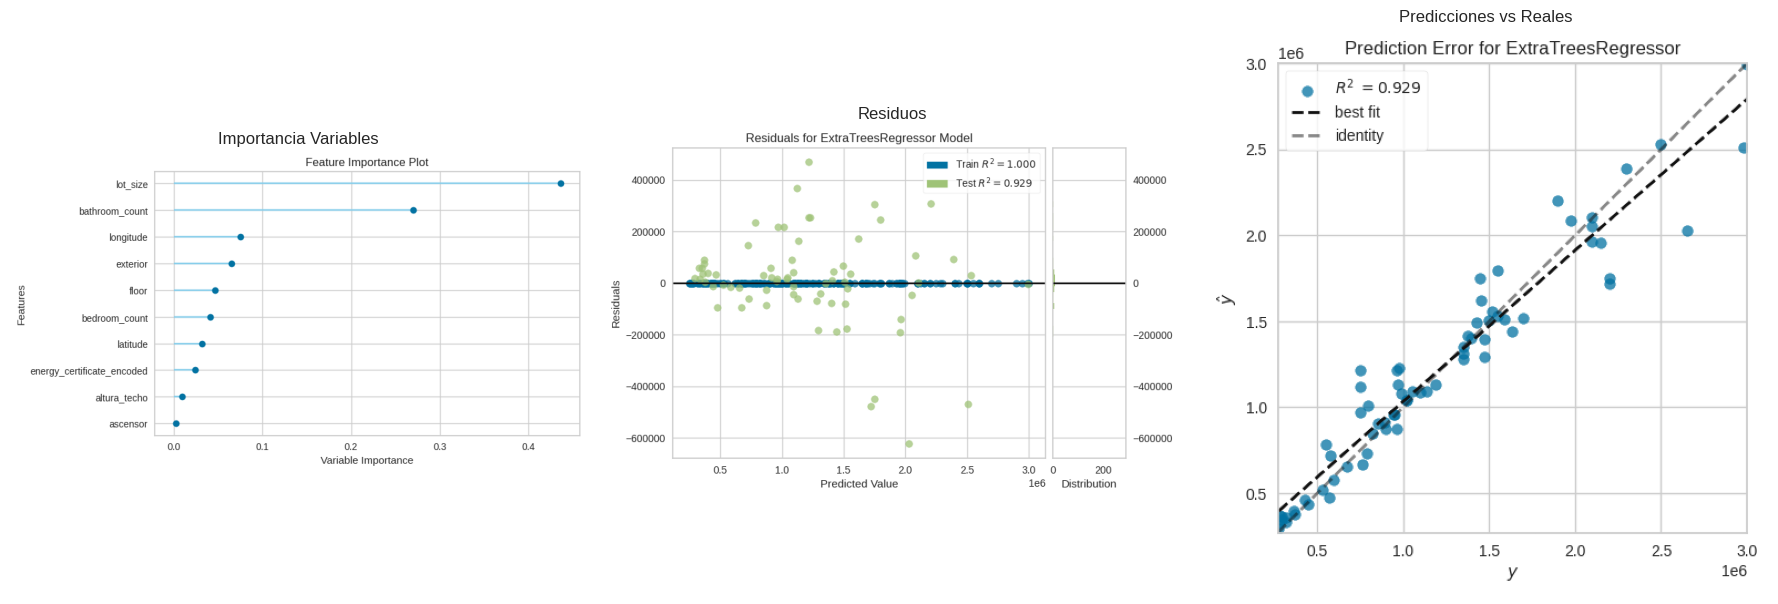


================= Análisis para CENTRO =================
----- Info preliminar -----
Nuḿero de datos:
407

Precio promedio: 1337.19 k€
Precio mínimo: 220.00 k€
Precio máximo: 3450.00 k€

Promedio de metros cuadrados: 228.42 m²
Promedio de baños: 3.01
Promedio de habitaciones: 3.46

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 0

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 15 valores atípicos
 - bedroom_count: 14 valores atípicos
 - floor: 12 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 45 valores atípicos
 - property_id: 45 valores atípicos
 - exterior: 48 valores atípicos
 - ascensor: 52 valores atípicos
 - altura_techo: 21 valores atípicos
 - dist_metro_m: 32 valores atípicos
 - energy_certificate_encoded: 0 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 291344.98
Error porcentual sobre precio promedio: 21.79%


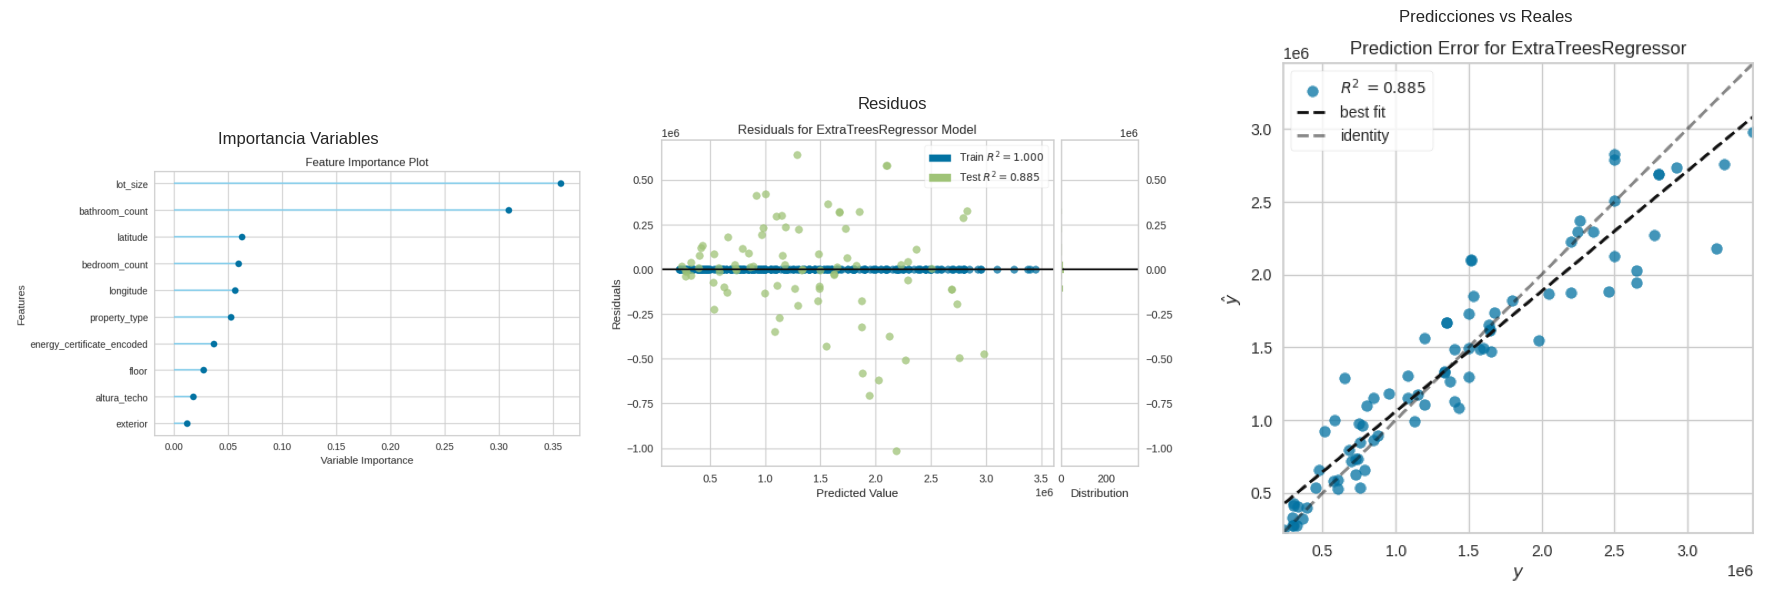


================= Análisis para ARGANZUELA =================
----- Info preliminar -----
Nuḿero de datos:
194

Precio promedio: 499.86 k€
Precio mínimo: 85.40 k€
Precio máximo: 1450.00 k€

Promedio de metros cuadrados: 87.32 m²
Promedio de baños: 1.44
Promedio de habitaciones: 2.45

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 6

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 0 valores atípicos
 - bedroom_count: 0 valores atípicos
 - floor: 0 valores atípicos
 - latitude: 1 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 0 valores atípicos
 - property_id: 22 valores atípicos
 - exterior: 0 valores atípicos
 - ascensor: 22 valores atípicos
 - altura_techo: 4 valores atípicos
 - dist_metro_m: 0 valores atípicos
 - energy_certificate_encoded: 28 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Huber Regressor
RMSE: 72038.49
Error porcentual sobre precio promedio: 15.15%

Visualizaci

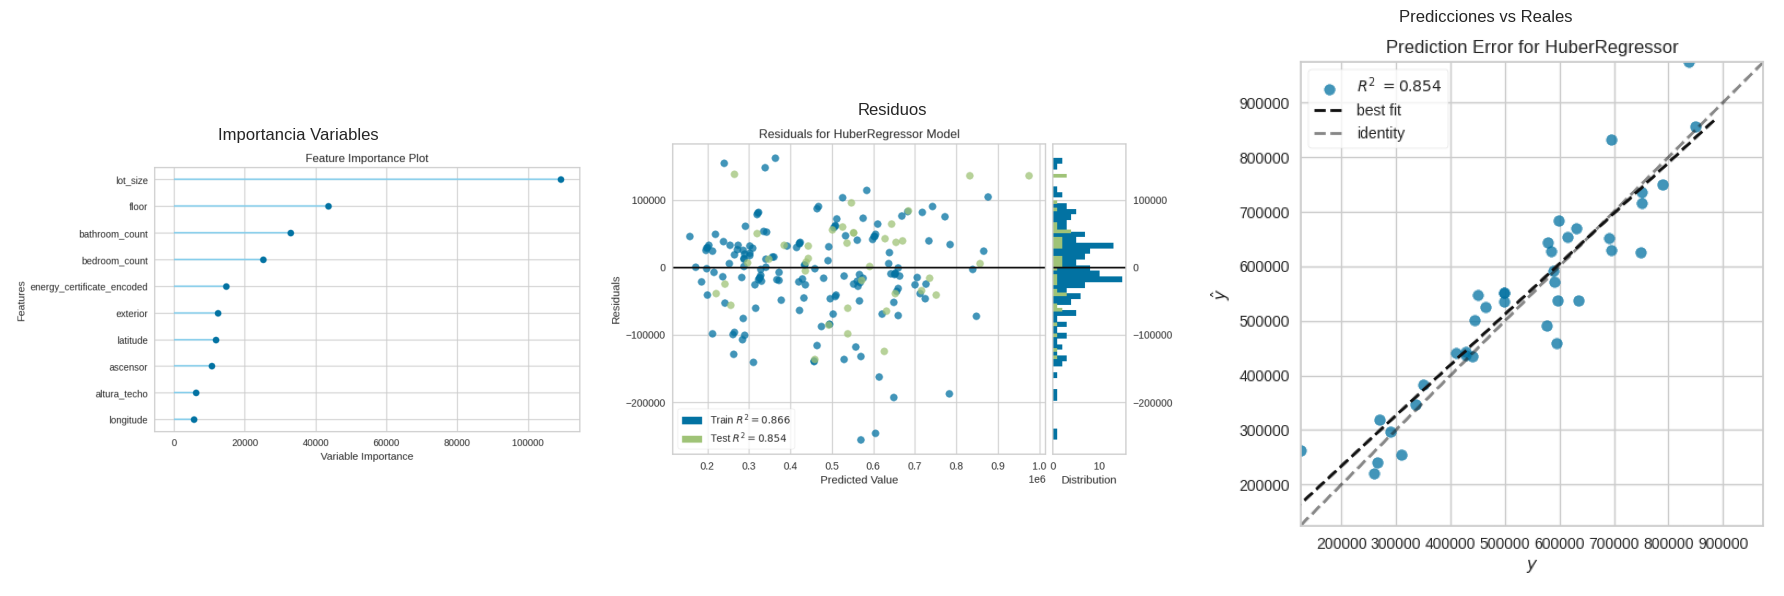


================= Análisis para RETIRO =================
----- Info preliminar -----
Nuḿero de datos:
193

Precio promedio: 1101.52 k€
Precio mínimo: 260.00 k€
Precio máximo: 2950.00 k€

Promedio de metros cuadrados: 129.06 m²
Promedio de baños: 2.07
Promedio de habitaciones: 2.79

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 21

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 7 valores atípicos
 - bedroom_count: 9 valores atípicos
 - floor: 1 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 6 valores atípicos
 - lot_size: 9 valores atípicos
 - property_id: 12 valores atípicos
 - exterior: 0 valores atípicos
 - ascensor: 12 valores atípicos
 - altura_techo: 7 valores atípicos
 - dist_metro_m: 2 valores atípicos
 - energy_certificate_encoded: 29 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 174032.24
Error porcentual sobre precio promedio: 19.00%

Visu

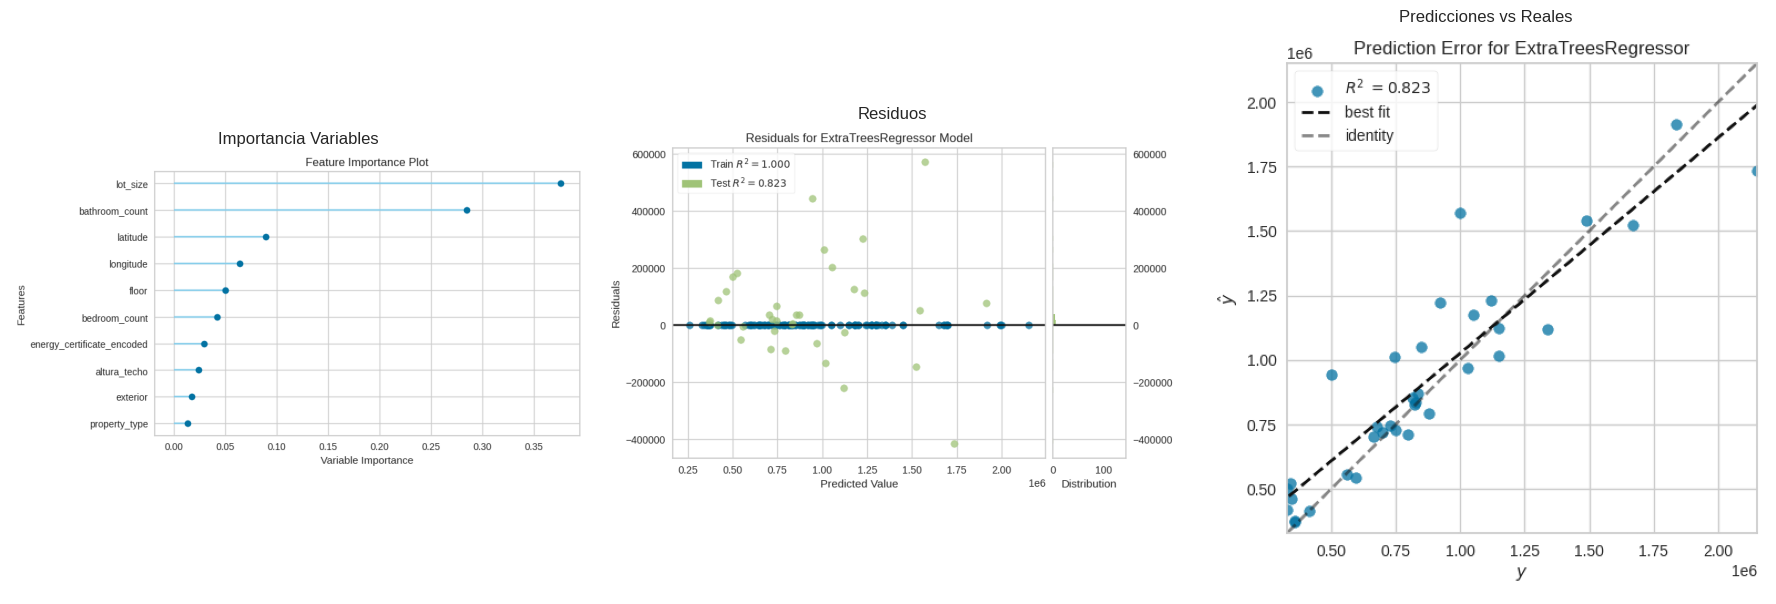

In [ ]:

features =[ 'bathroom_count', 'bedroom_count', 'floor',
       'latitude', 'longitude', 'lot_size',
       'property_type', 'neighborhood', 'exterior', 'ascensor', 'altura_techo', 'energy_certificate_encoded']

df_procesados = analizar_por_barrio(df, neighborhood_dict, features)

## 3.3 techo + distancia metro


================= Análisis para CHAMBERÍ =================
----- Info preliminar -----
Nuḿero de datos:
365

Precio promedio: 1317.66 k€
Precio mínimo: 250.00 k€
Precio máximo: 3400.00 k€

Promedio de metros cuadrados: 149.39 m²
Promedio de baños: 2.35
Promedio de habitaciones: 2.94

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 18

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 0 valores atípicos
 - bedroom_count: 1 valores atípicos
 - floor: 3 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 6 valores atípicos
 - property_id: 39 valores atípicos
 - exterior: 70 valores atípicos
 - ascensor: 22 valores atípicos
 - altura_techo: 29 valores atípicos
 - dist_metro_m: 0 valores atípicos
 - energy_certificate_encoded: 34 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 223993.72
Error porcentual sobre precio promedio: 18.44%



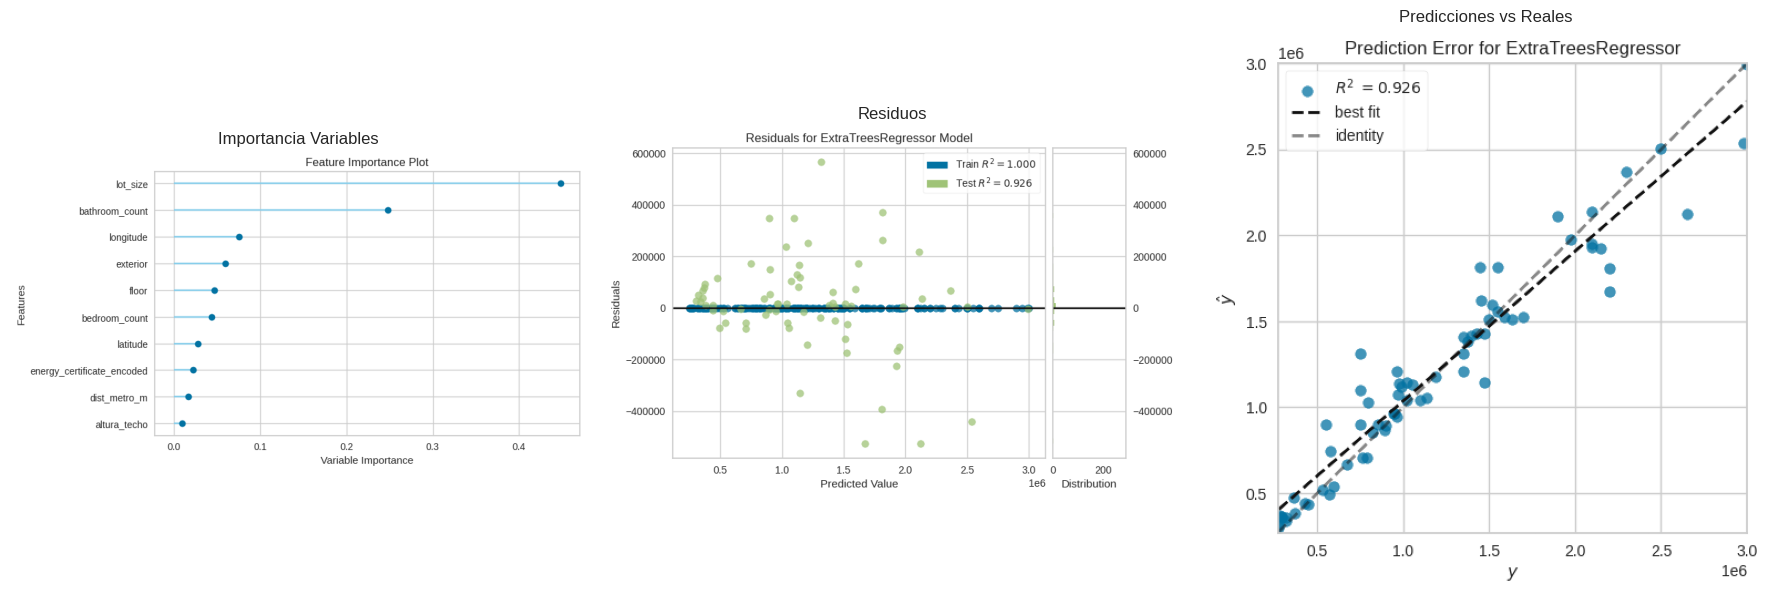


================= Análisis para CENTRO =================
----- Info preliminar -----
Nuḿero de datos:
407

Precio promedio: 1337.19 k€
Precio mínimo: 220.00 k€
Precio máximo: 3450.00 k€

Promedio de metros cuadrados: 228.42 m²
Promedio de baños: 3.01
Promedio de habitaciones: 3.46

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 0

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 15 valores atípicos
 - bedroom_count: 14 valores atípicos
 - floor: 12 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 45 valores atípicos
 - property_id: 45 valores atípicos
 - exterior: 48 valores atípicos
 - ascensor: 52 valores atípicos
 - altura_techo: 21 valores atípicos
 - dist_metro_m: 32 valores atípicos
 - energy_certificate_encoded: 0 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 299758.23
Error porcentual sobre precio promedio: 22.42%


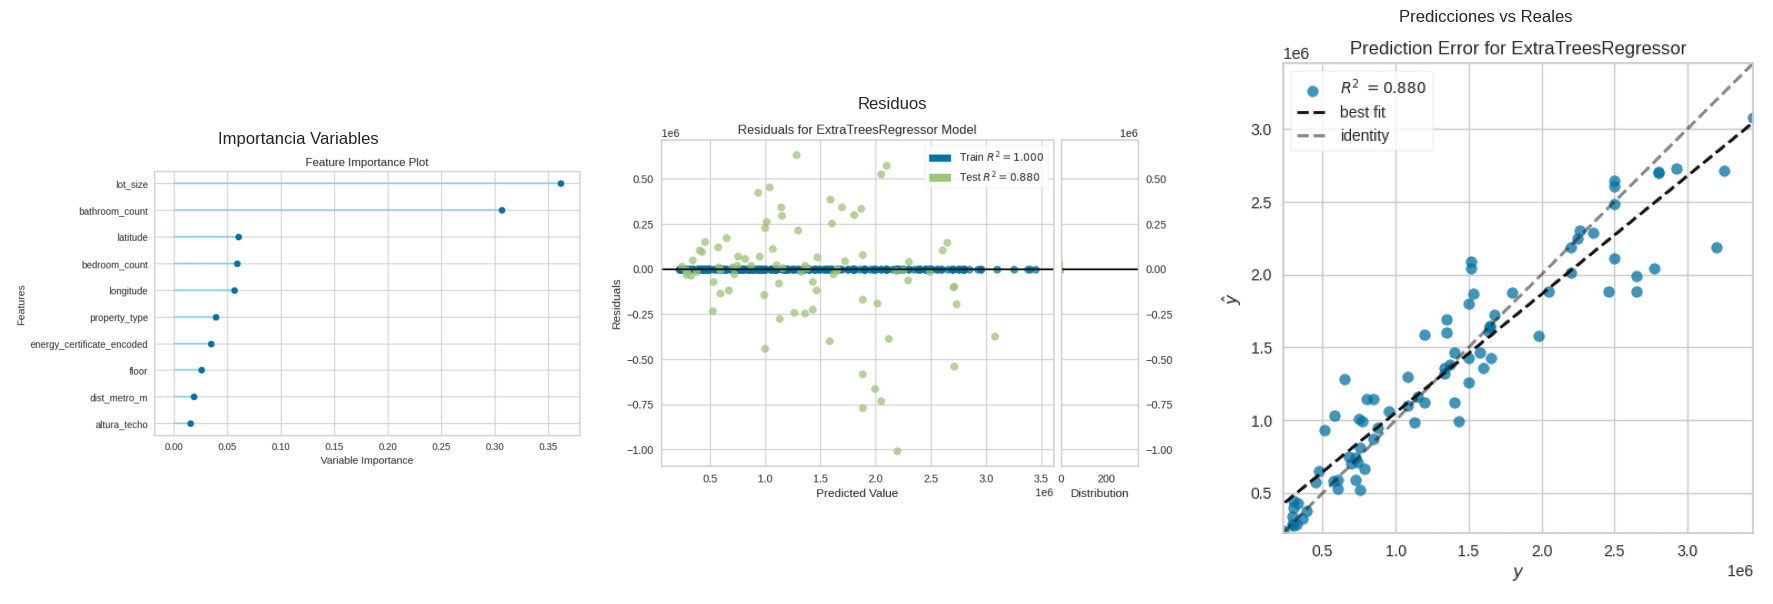


================= Análisis para ARGANZUELA =================
----- Info preliminar -----
Nuḿero de datos:
194

Precio promedio: 499.86 k€
Precio mínimo: 85.40 k€
Precio máximo: 1450.00 k€

Promedio de metros cuadrados: 87.32 m²
Promedio de baños: 1.44
Promedio de habitaciones: 2.45

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 6

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 0 valores atípicos
 - bedroom_count: 0 valores atípicos
 - floor: 0 valores atípicos
 - latitude: 1 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 0 valores atípicos
 - property_id: 22 valores atípicos
 - exterior: 0 valores atípicos
 - ascensor: 22 valores atípicos
 - altura_techo: 4 valores atípicos
 - dist_metro_m: 0 valores atípicos
 - energy_certificate_encoded: 28 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Ridge Regression
RMSE: 71560.10
Error porcentual sobre precio promedio: 15.05%

Visualizac

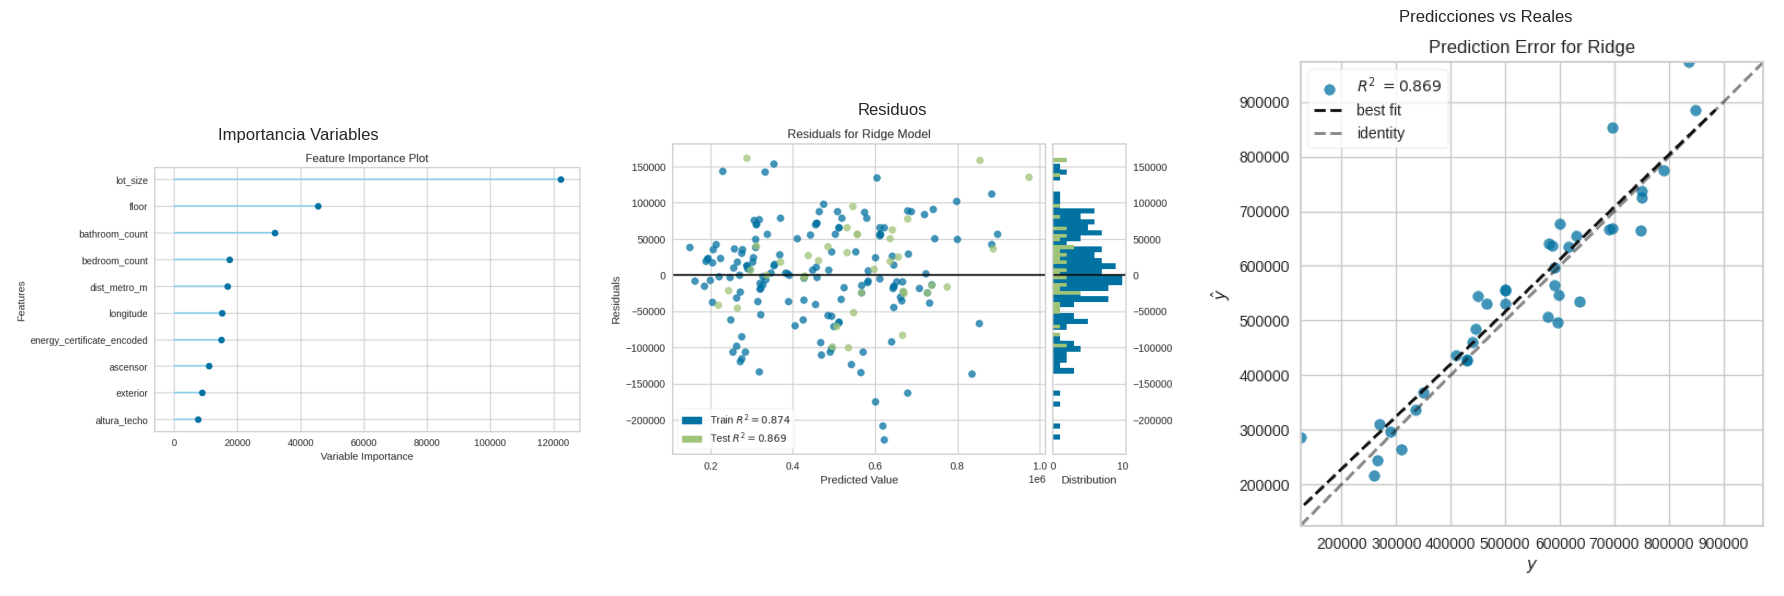


================= Análisis para RETIRO =================
----- Info preliminar -----
Nuḿero de datos:
193

Precio promedio: 1101.52 k€
Precio mínimo: 260.00 k€
Precio máximo: 2950.00 k€

Promedio de metros cuadrados: 129.06 m²
Promedio de baños: 2.07
Promedio de habitaciones: 2.79

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 21

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 7 valores atípicos
 - bedroom_count: 9 valores atípicos
 - floor: 1 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 6 valores atípicos
 - lot_size: 9 valores atípicos
 - property_id: 12 valores atípicos
 - exterior: 0 valores atípicos
 - ascensor: 12 valores atípicos
 - altura_techo: 7 valores atípicos
 - dist_metro_m: 2 valores atípicos
 - energy_certificate_encoded: 29 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 182508.91
Error porcentual sobre precio promedio: 19.92%

Visu

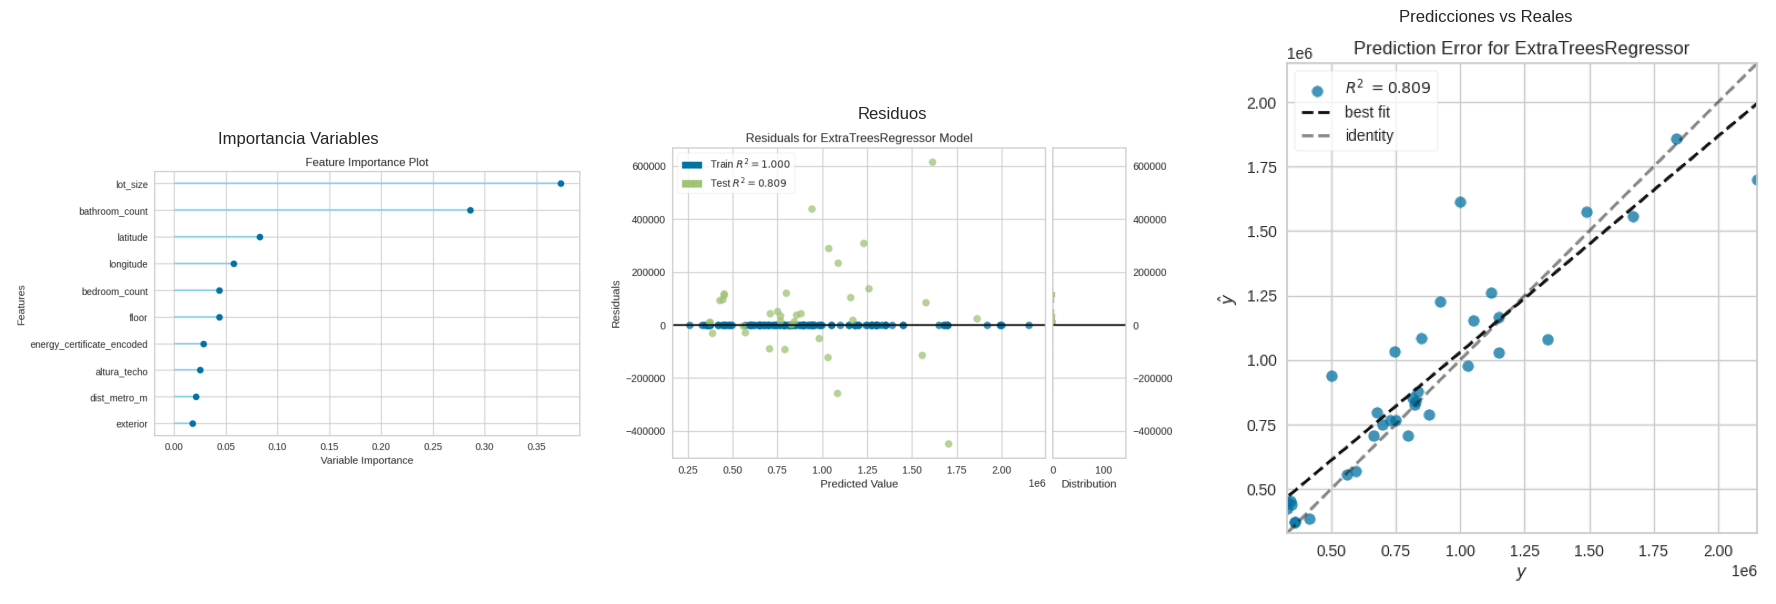

In [ ]:
features =[ 'bathroom_count', 'bedroom_count', 'floor',
       'latitude', 'longitude', 'lot_size',
       'property_type', 'neighborhood', 'exterior', 'ascensor', 'altura_techo',
        'dist_metro_m', 'energy_certificate_encoded']
df_procesados = analizar_por_barrio(df, neighborhood_dict, features)

## 3.4 Tipo suelo


================= Análisis para CHAMBERÍ =================
----- Info preliminar -----
Nuḿero de datos:
365

Precio promedio: 1317.66 k€
Precio mínimo: 250.00 k€
Precio máximo: 3400.00 k€

Promedio de metros cuadrados: 149.39 m²
Promedio de baños: 2.35
Promedio de habitaciones: 2.94

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 18

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 0 valores atípicos
 - bedroom_count: 1 valores atípicos
 - floor: 3 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 6 valores atípicos
 - property_id: 39 valores atípicos
 - exterior: 70 valores atípicos
 - ascensor: 22 valores atípicos
 - altura_techo: 29 valores atípicos
 - dist_metro_m: 0 valores atípicos
 - energy_certificate_encoded: 34 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 224429.56
Error porcentual sobre precio promedio: 18.47%



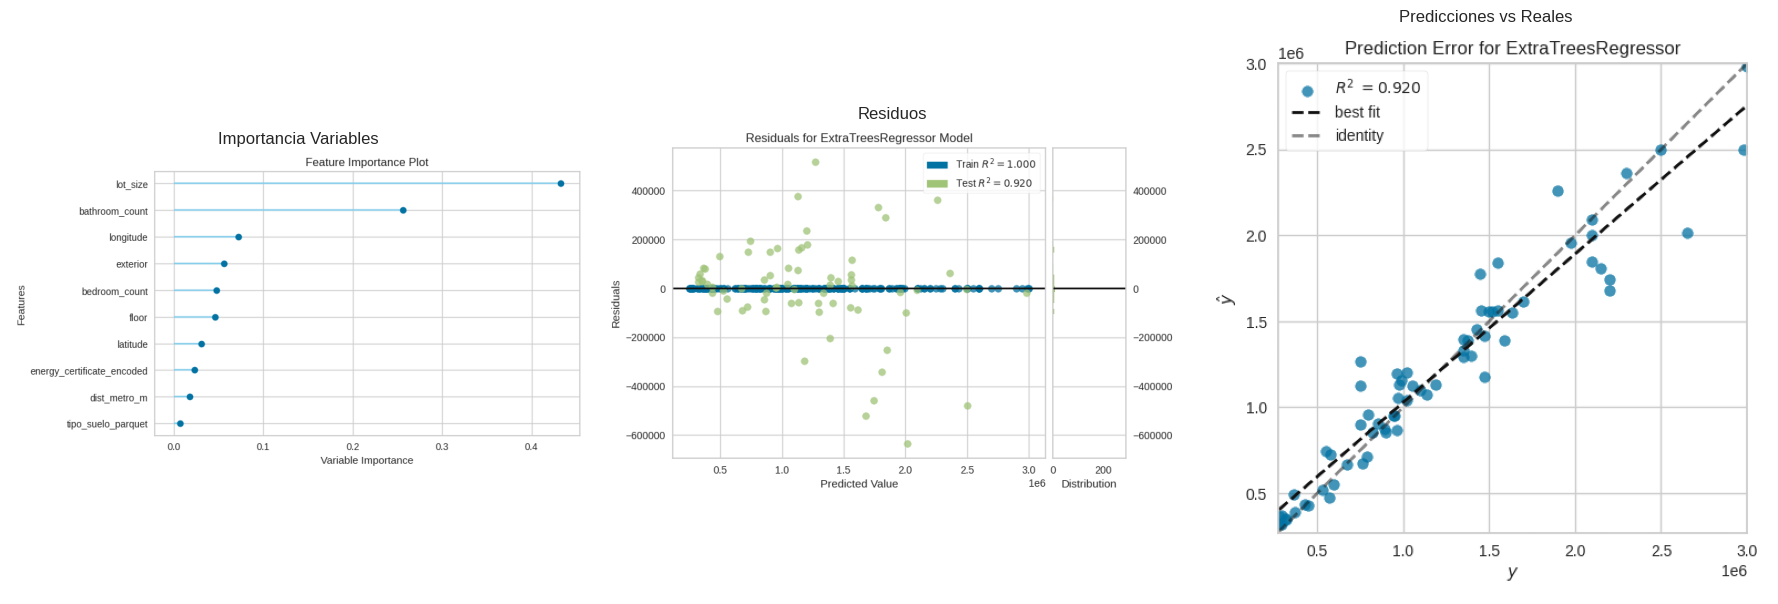


================= Análisis para CENTRO =================
----- Info preliminar -----
Nuḿero de datos:
407

Precio promedio: 1337.19 k€
Precio mínimo: 220.00 k€
Precio máximo: 3450.00 k€

Promedio de metros cuadrados: 228.42 m²
Promedio de baños: 3.01
Promedio de habitaciones: 3.46

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 0

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 15 valores atípicos
 - bedroom_count: 14 valores atípicos
 - floor: 12 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 45 valores atípicos
 - property_id: 45 valores atípicos
 - exterior: 48 valores atípicos
 - ascensor: 52 valores atípicos
 - altura_techo: 21 valores atípicos
 - dist_metro_m: 32 valores atípicos
 - energy_certificate_encoded: 0 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 301427.07
Error porcentual sobre precio promedio: 22.54%


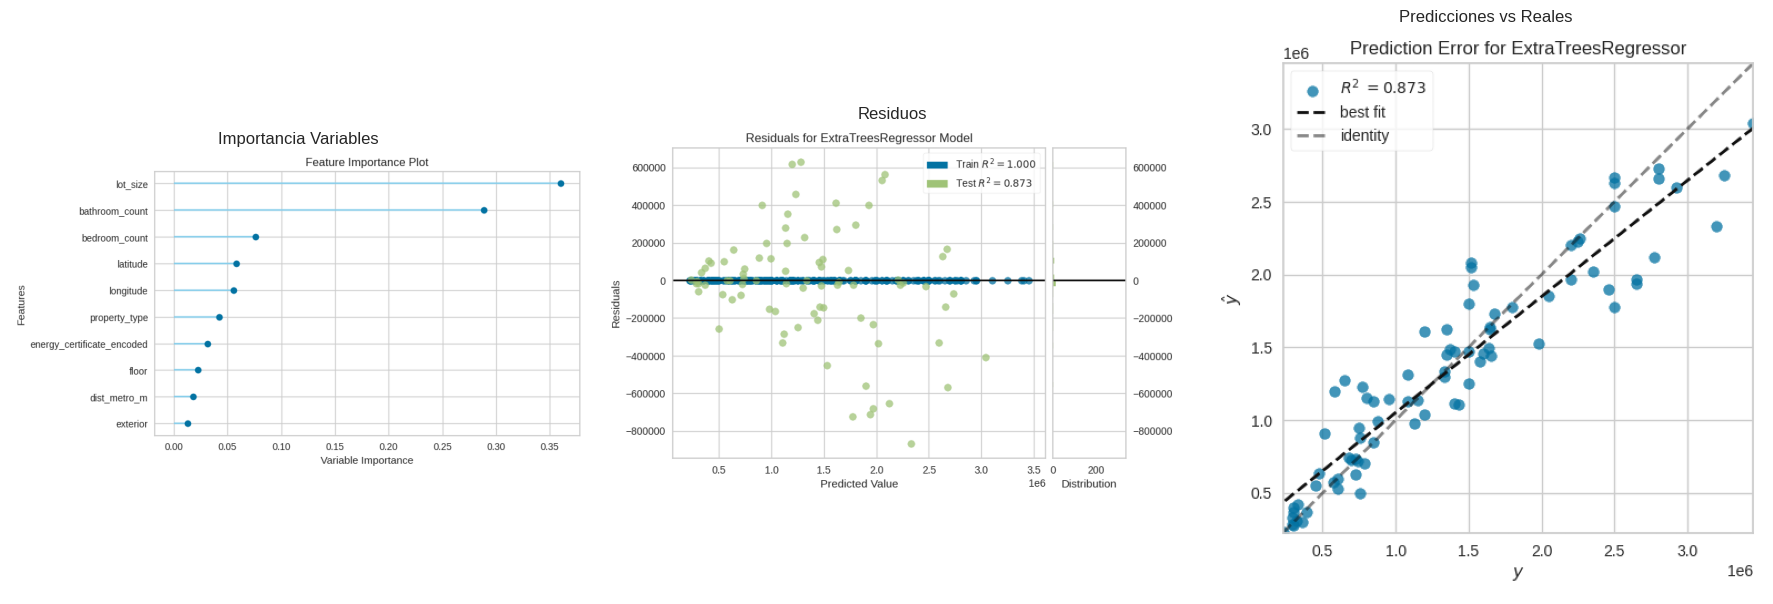


================= Análisis para ARGANZUELA =================
----- Info preliminar -----
Nuḿero de datos:
194

Precio promedio: 499.86 k€
Precio mínimo: 85.40 k€
Precio máximo: 1450.00 k€

Promedio de metros cuadrados: 87.32 m²
Promedio de baños: 1.44
Promedio de habitaciones: 2.45

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 6

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 0 valores atípicos
 - bedroom_count: 0 valores atípicos
 - floor: 0 valores atípicos
 - latitude: 1 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 0 valores atípicos
 - property_id: 22 valores atípicos
 - exterior: 0 valores atípicos
 - ascensor: 22 valores atípicos
 - altura_techo: 4 valores atípicos
 - dist_metro_m: 0 valores atípicos
 - energy_certificate_encoded: 28 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Ridge Regression
RMSE: 73691.39
Error porcentual sobre precio promedio: 15.49%

Visualizac

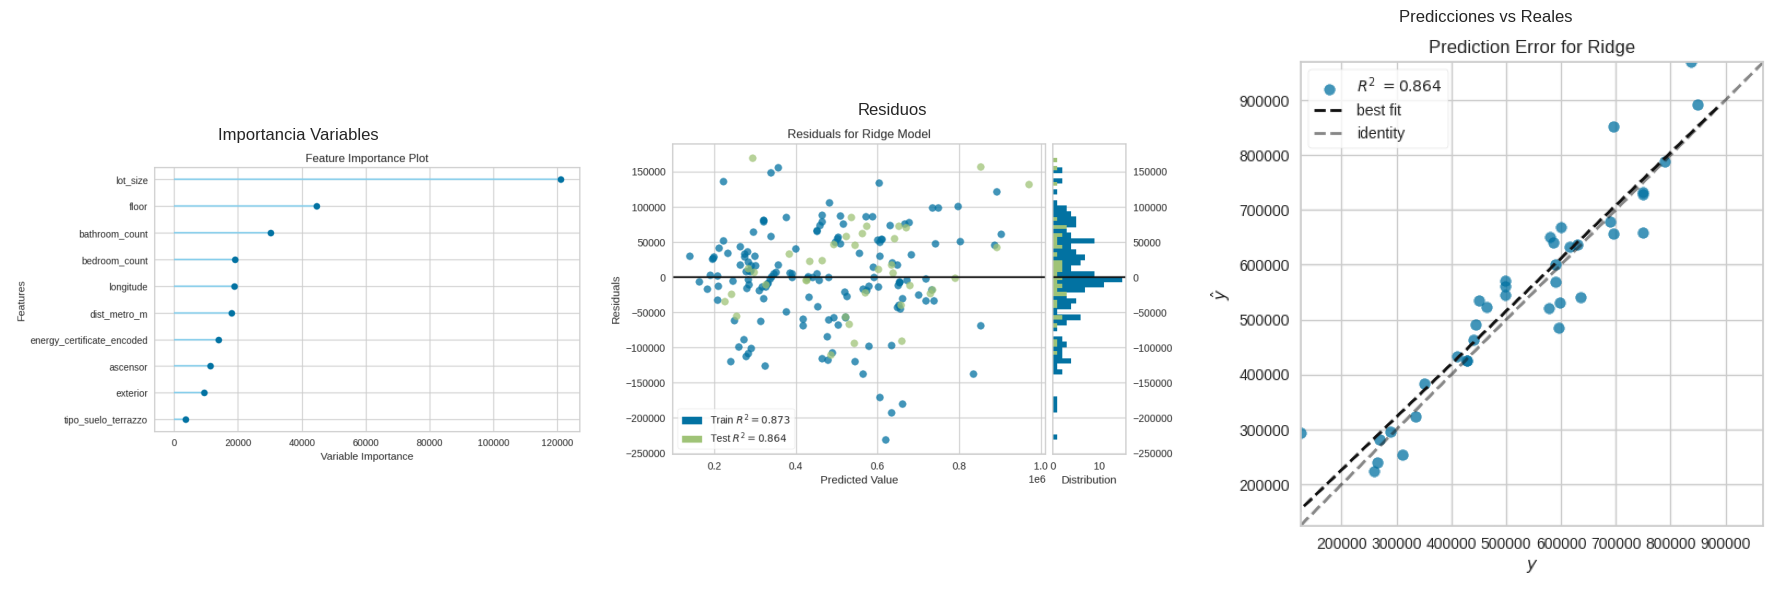


================= Análisis para RETIRO =================
----- Info preliminar -----
Nuḿero de datos:
193

Precio promedio: 1101.52 k€
Precio mínimo: 260.00 k€
Precio máximo: 2950.00 k€

Promedio de metros cuadrados: 129.06 m²
Promedio de baños: 2.07
Promedio de habitaciones: 2.79

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 21

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 7 valores atípicos
 - bedroom_count: 9 valores atípicos
 - floor: 1 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 6 valores atípicos
 - lot_size: 9 valores atípicos
 - property_id: 12 valores atípicos
 - exterior: 0 valores atípicos
 - ascensor: 12 valores atípicos
 - altura_techo: 7 valores atípicos
 - dist_metro_m: 2 valores atípicos
 - energy_certificate_encoded: 29 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 190491.87
Error porcentual sobre precio promedio: 20.79%

Visu

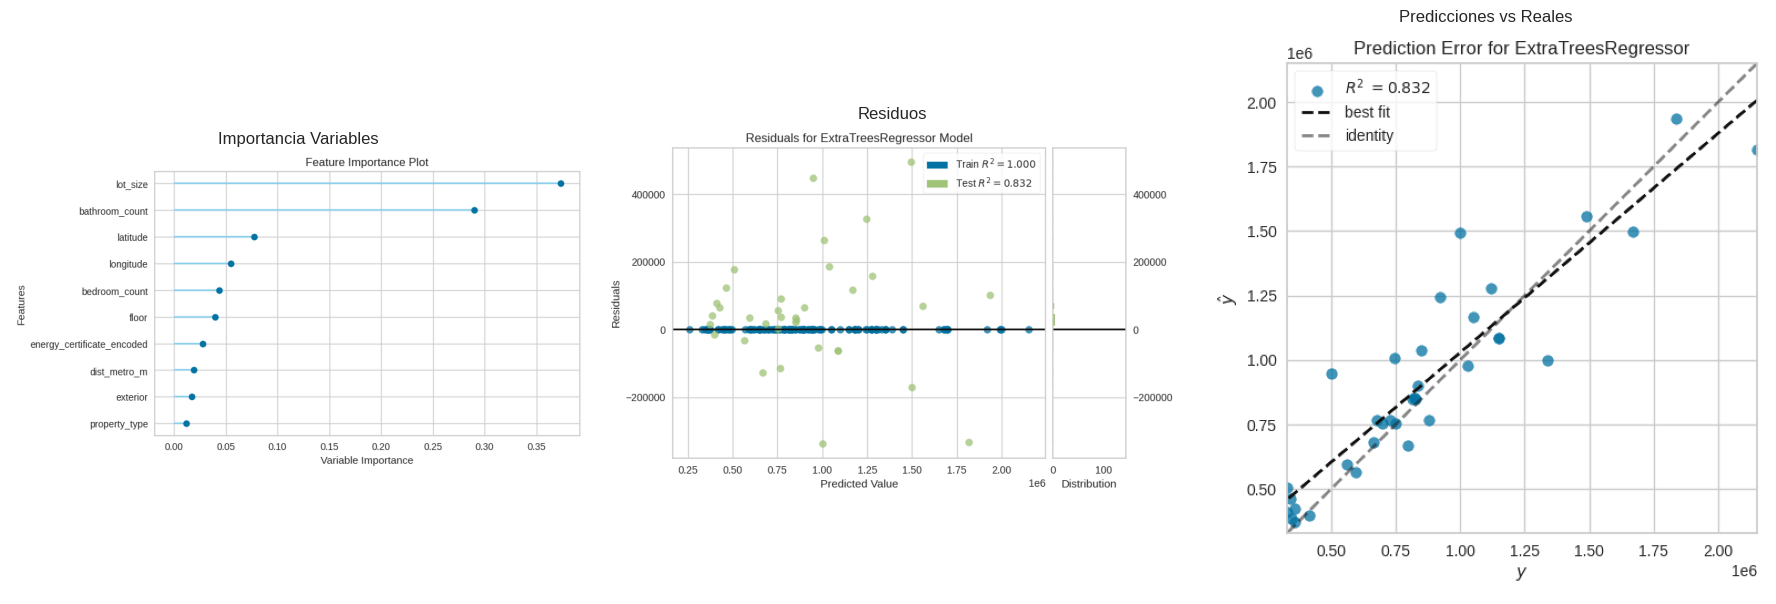

In [ ]:
features = ['bathroom_count', 'bedroom_count', 'floor',
       'latitude', 'longitude', 'lot_size',
       'property_type', 'neighborhood', 'exterior', 'ascensor',
       'tipo_suelo','dist_metro_m', 'energy_certificate_encoded']

df_procesados = analizar_por_barrio(df, neighborhood_dict, features)

## 3.5 Estilo arquitectonico


================= Análisis para CHAMBERÍ =================
----- Info preliminar -----
Nuḿero de datos:
365

Precio promedio: 1317.66 k€
Precio mínimo: 250.00 k€
Precio máximo: 3400.00 k€

Promedio de metros cuadrados: 149.39 m²
Promedio de baños: 2.35
Promedio de habitaciones: 2.94

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 18

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 0 valores atípicos
 - bedroom_count: 1 valores atípicos
 - floor: 3 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 6 valores atípicos
 - property_id: 39 valores atípicos
 - exterior: 70 valores atípicos
 - ascensor: 22 valores atípicos
 - altura_techo: 29 valores atípicos
 - dist_metro_m: 0 valores atípicos
 - energy_certificate_encoded: 34 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 224913.70
Error porcentual sobre precio promedio: 18.51%



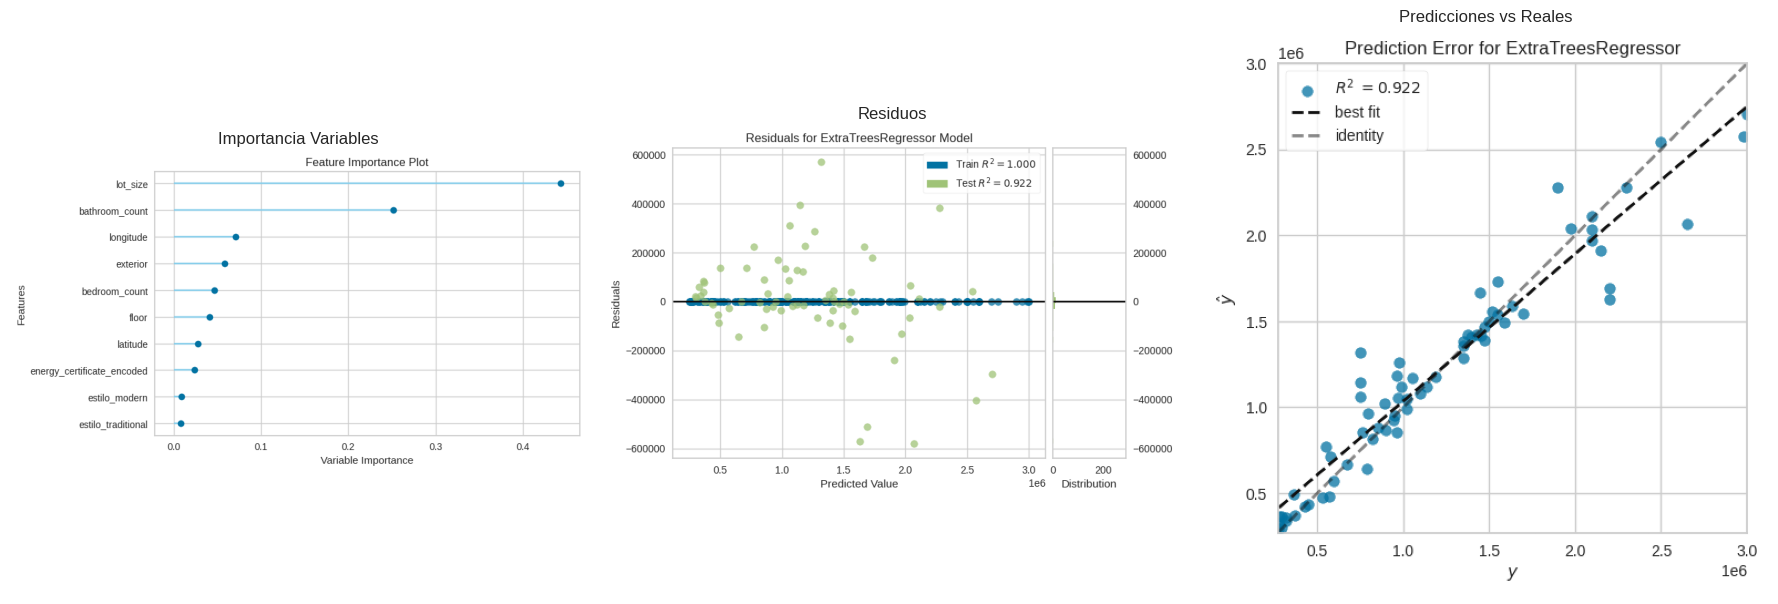


================= Análisis para CENTRO =================
----- Info preliminar -----
Nuḿero de datos:
407

Precio promedio: 1337.19 k€
Precio mínimo: 220.00 k€
Precio máximo: 3450.00 k€

Promedio de metros cuadrados: 228.42 m²
Promedio de baños: 3.01
Promedio de habitaciones: 3.46

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 0

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 15 valores atípicos
 - bedroom_count: 14 valores atípicos
 - floor: 12 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 45 valores atípicos
 - property_id: 45 valores atípicos
 - exterior: 48 valores atípicos
 - ascensor: 52 valores atípicos
 - altura_techo: 21 valores atípicos
 - dist_metro_m: 32 valores atípicos
 - energy_certificate_encoded: 0 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 299996.55
Error porcentual sobre precio promedio: 22.43%


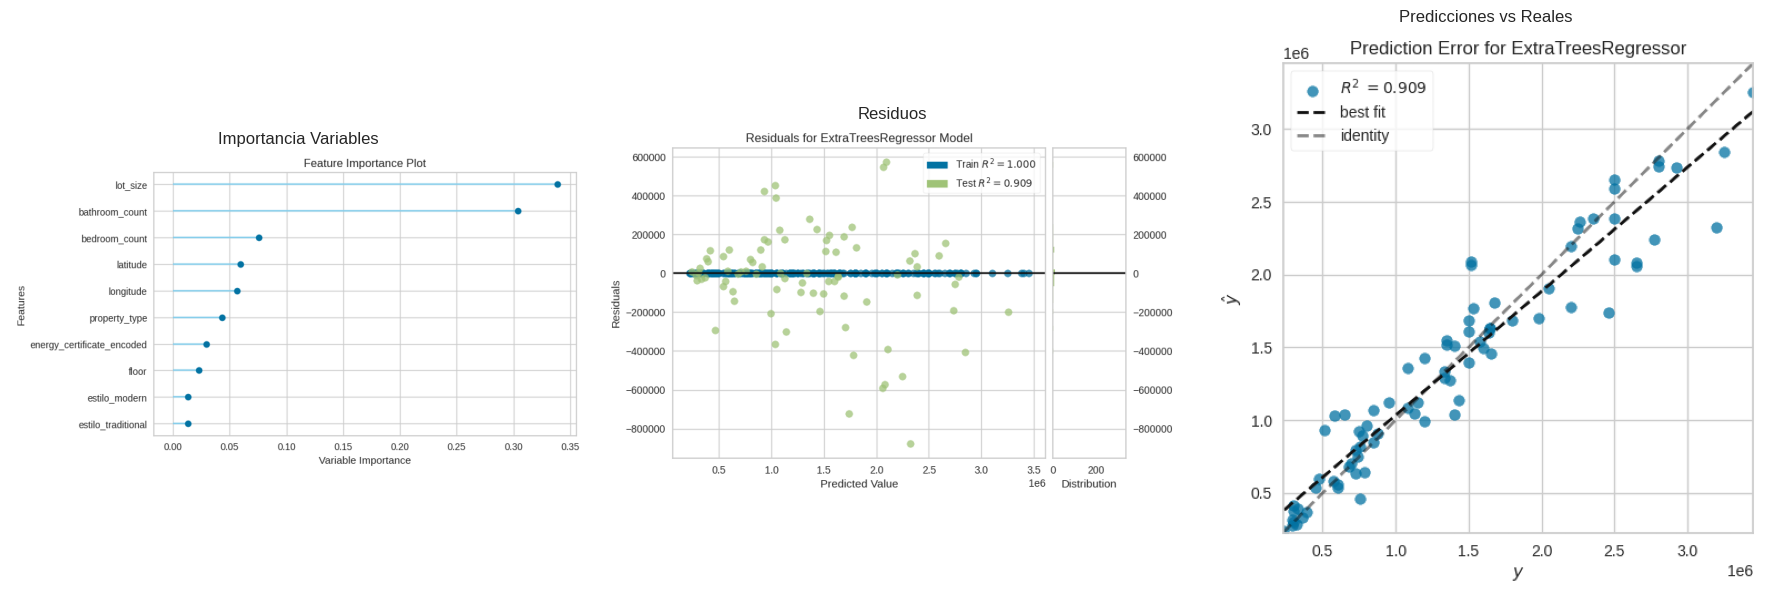


================= Análisis para ARGANZUELA =================
----- Info preliminar -----
Nuḿero de datos:
194

Precio promedio: 499.86 k€
Precio mínimo: 85.40 k€
Precio máximo: 1450.00 k€

Promedio de metros cuadrados: 87.32 m²
Promedio de baños: 1.44
Promedio de habitaciones: 2.45

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 6

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 0 valores atípicos
 - bedroom_count: 0 valores atípicos
 - floor: 0 valores atípicos
 - latitude: 1 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 0 valores atípicos
 - property_id: 22 valores atípicos
 - exterior: 0 valores atípicos
 - ascensor: 22 valores atípicos
 - altura_techo: 4 valores atípicos
 - dist_metro_m: 0 valores atípicos
 - energy_certificate_encoded: 28 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Light Gradient Boosting Machine
RMSE: 72717.06
Error porcentual sobre precio promedio: 15.

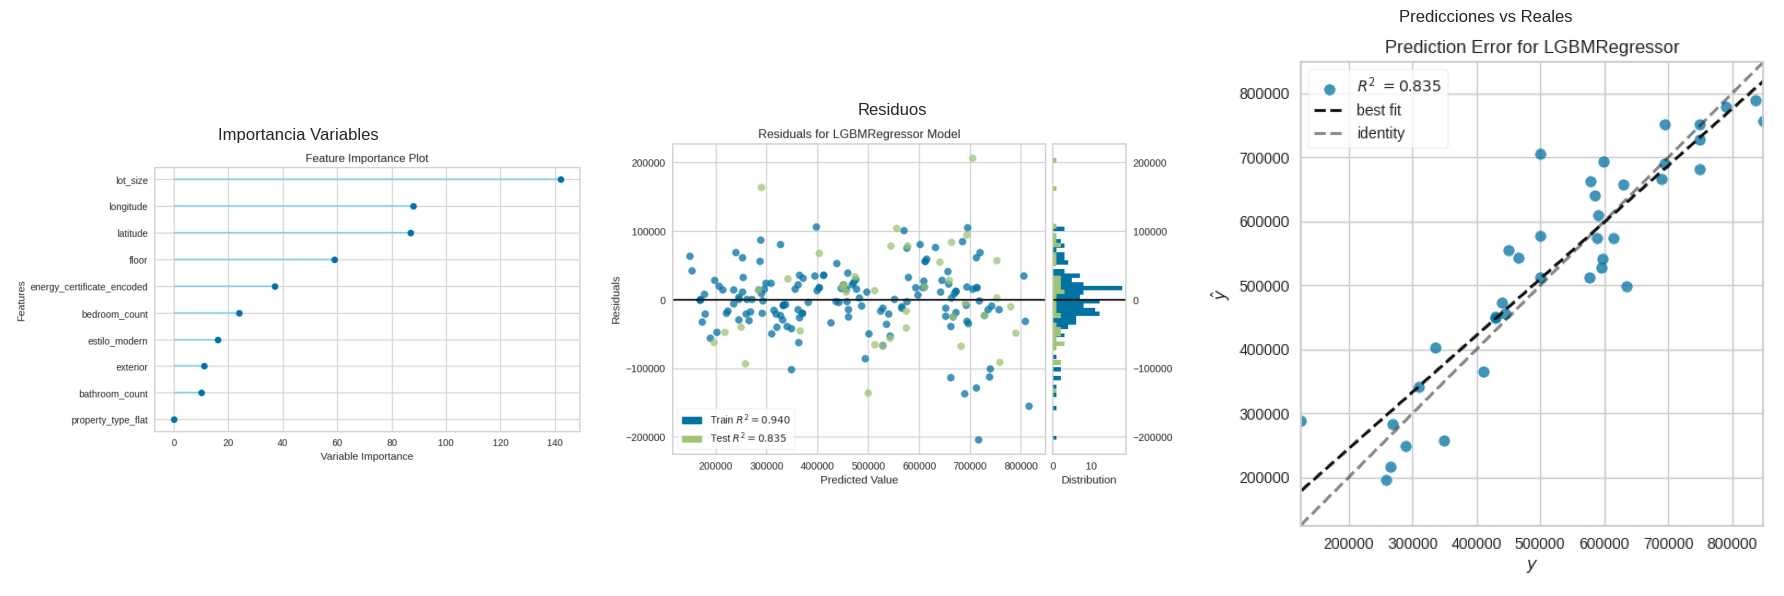


================= Análisis para RETIRO =================
----- Info preliminar -----
Nuḿero de datos:
193

Precio promedio: 1101.52 k€
Precio mínimo: 260.00 k€
Precio máximo: 2950.00 k€

Promedio de metros cuadrados: 129.06 m²
Promedio de baños: 2.07
Promedio de habitaciones: 2.79

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 21

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 7 valores atípicos
 - bedroom_count: 9 valores atípicos
 - floor: 1 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 6 valores atípicos
 - lot_size: 9 valores atípicos
 - property_id: 12 valores atípicos
 - exterior: 0 valores atípicos
 - ascensor: 12 valores atípicos
 - altura_techo: 7 valores atípicos
 - dist_metro_m: 2 valores atípicos
 - energy_certificate_encoded: 29 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 179190.10
Error porcentual sobre precio promedio: 19.56%

Visu

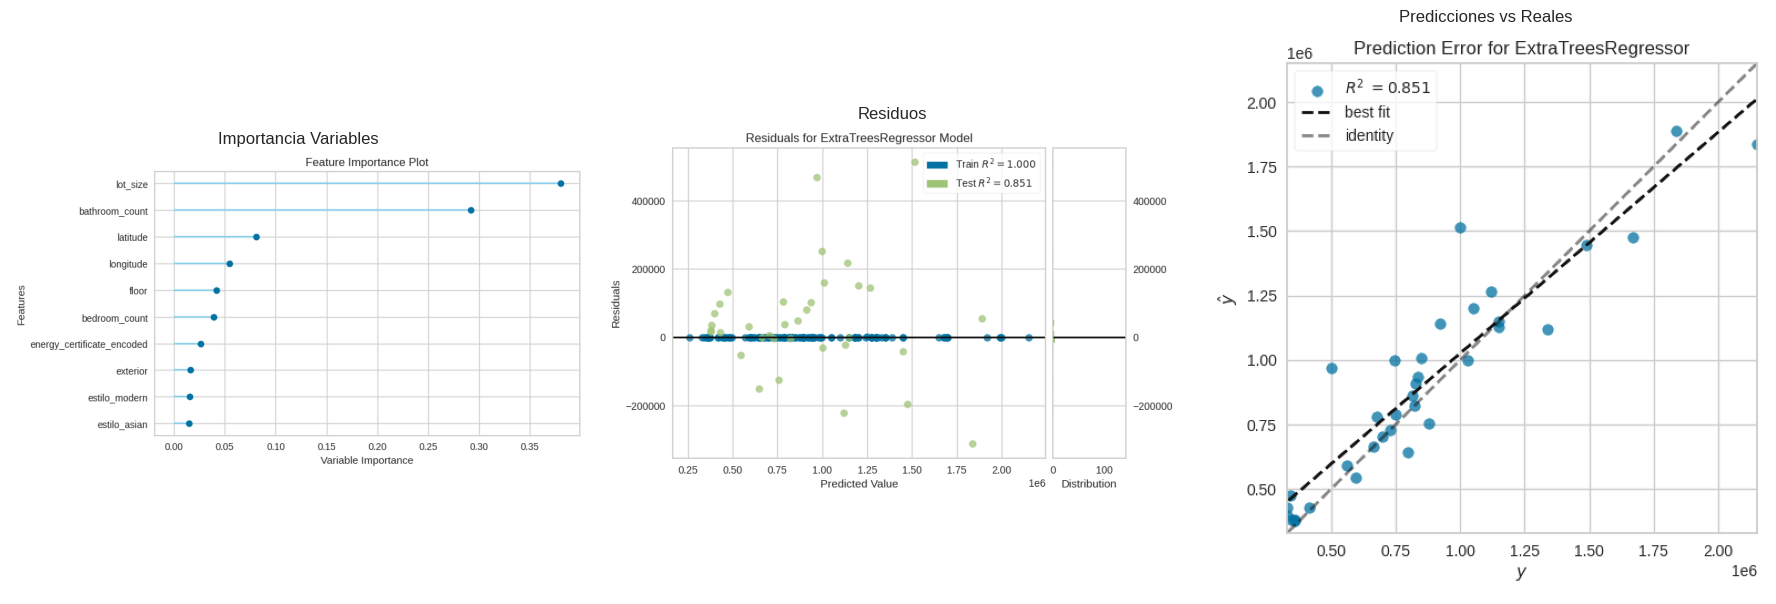

In [ ]:

features =[ 'bathroom_count', 'bedroom_count', 'floor',
       'latitude', 'longitude', 'lot_size',
       'property_type', 'neighborhood', 'exterior', 'ascensor', 'estilo', 'energy_certificate_encoded']
df_procesados = analizar_por_barrio(df, neighborhood_dict, features)

# 3.6 Aire acondicionado


================= Análisis para CHAMBERÍ =================
----- Info preliminar -----
Nuḿero de datos:
365

Precio promedio: 1317.66 k€
Precio mínimo: 250.00 k€
Precio máximo: 3400.00 k€

Promedio de metros cuadrados: 149.39 m²
Promedio de baños: 2.35
Promedio de habitaciones: 2.94

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 18

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 0 valores atípicos
 - bedroom_count: 1 valores atípicos
 - floor: 3 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 6 valores atípicos
 - property_id: 39 valores atípicos
 - exterior: 70 valores atípicos
 - ascensor: 22 valores atípicos
 - altura_techo: 29 valores atípicos
 - dist_metro_m: 0 valores atípicos
 - aire_acondicionado: 0 valores atípicos
 - energy_certificate_encoded: 34 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 223978.27
Error 

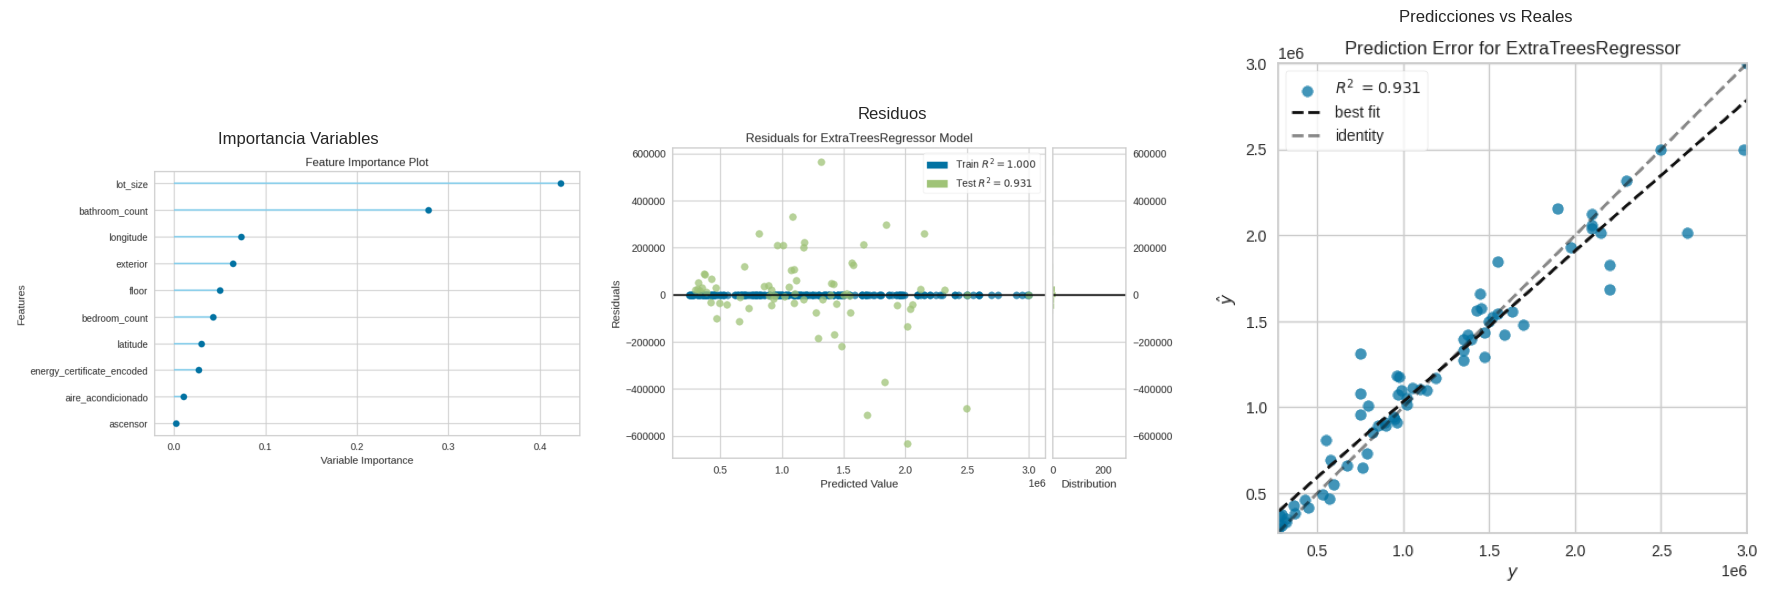


================= Análisis para CENTRO =================
----- Info preliminar -----
Nuḿero de datos:
407

Precio promedio: 1337.19 k€
Precio mínimo: 220.00 k€
Precio máximo: 3450.00 k€

Promedio de metros cuadrados: 228.42 m²
Promedio de baños: 3.01
Promedio de habitaciones: 3.46

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 0

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 15 valores atípicos
 - bedroom_count: 14 valores atípicos
 - floor: 12 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 45 valores atípicos
 - property_id: 45 valores atípicos
 - exterior: 48 valores atípicos
 - ascensor: 52 valores atípicos
 - altura_techo: 21 valores atípicos
 - dist_metro_m: 32 valores atípicos
 - aire_acondicionado: 95 valores atípicos
 - energy_certificate_encoded: 0 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 294158.81
Erro

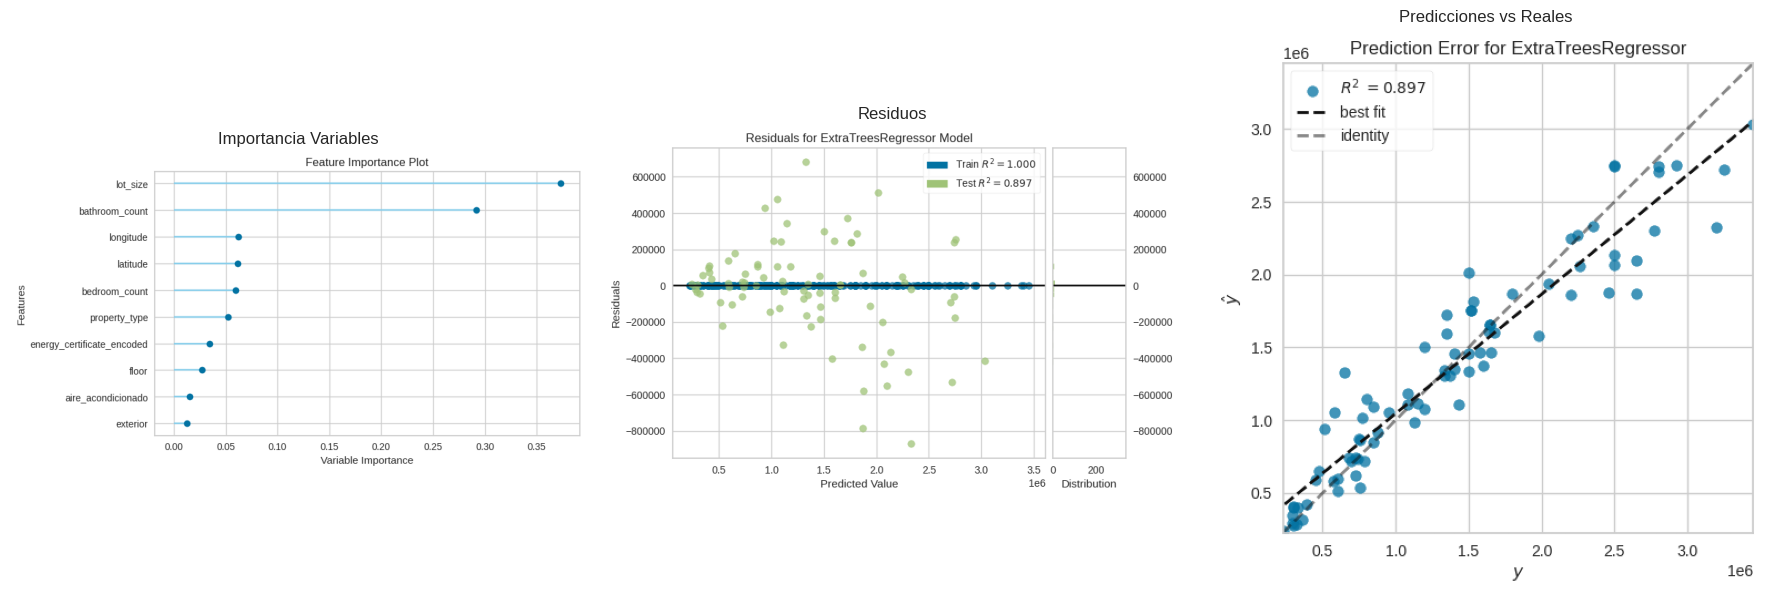


================= Análisis para ARGANZUELA =================
----- Info preliminar -----
Nuḿero de datos:
194

Precio promedio: 499.86 k€
Precio mínimo: 85.40 k€
Precio máximo: 1450.00 k€

Promedio de metros cuadrados: 87.32 m²
Promedio de baños: 1.44
Promedio de habitaciones: 2.45

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 6

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 0 valores atípicos
 - bedroom_count: 0 valores atípicos
 - floor: 0 valores atípicos
 - latitude: 1 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 0 valores atípicos
 - property_id: 22 valores atípicos
 - exterior: 0 valores atípicos
 - ascensor: 22 valores atípicos
 - altura_techo: 4 valores atípicos
 - dist_metro_m: 0 valores atípicos
 - aire_acondicionado: 0 valores atípicos
 - energy_certificate_encoded: 28 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Light Gradient Boosting Machine
RMSE: 72277.18
E

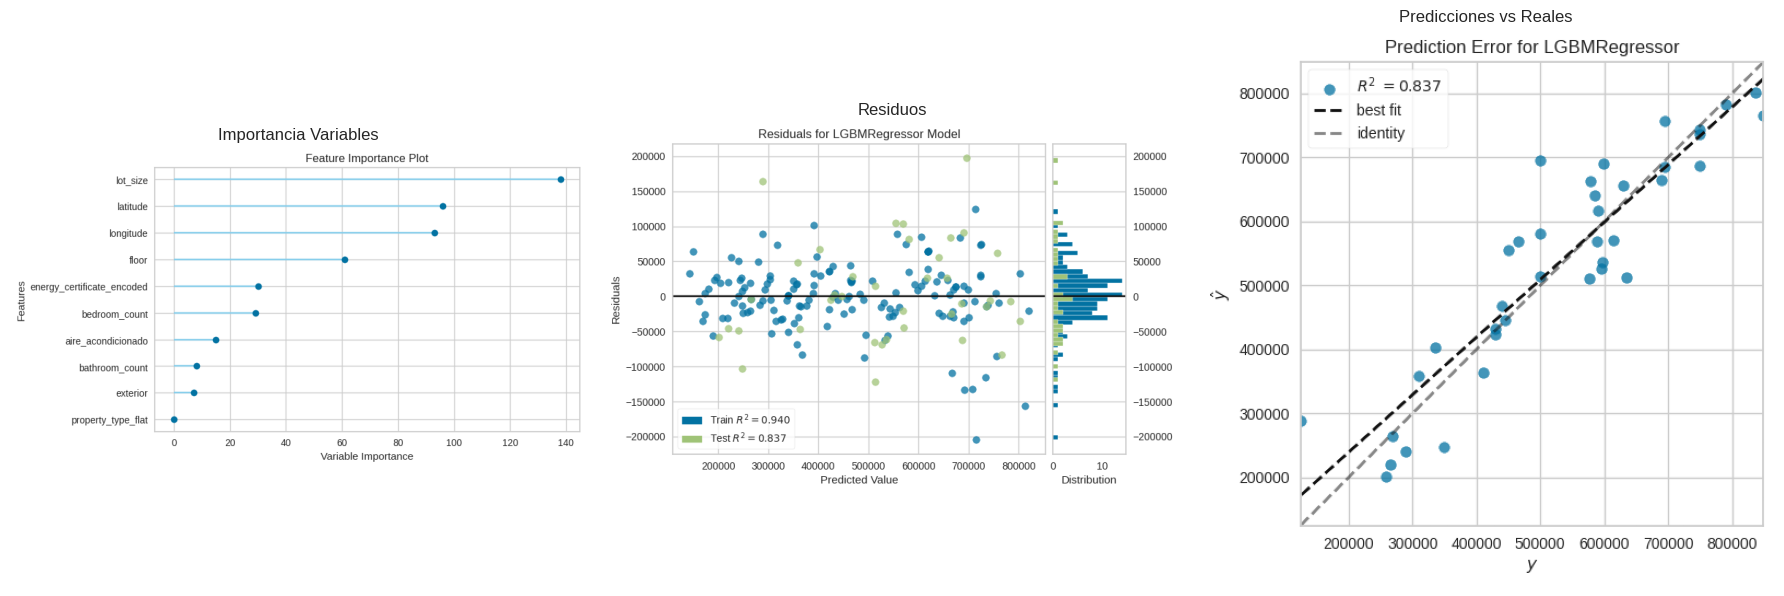


================= Análisis para RETIRO =================
----- Info preliminar -----
Nuḿero de datos:
193

Precio promedio: 1101.52 k€
Precio mínimo: 260.00 k€
Precio máximo: 2950.00 k€

Promedio de metros cuadrados: 129.06 m²
Promedio de baños: 2.07
Promedio de habitaciones: 2.79

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 21

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 7 valores atípicos
 - bedroom_count: 9 valores atípicos
 - floor: 1 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 6 valores atípicos
 - lot_size: 9 valores atípicos
 - property_id: 12 valores atípicos
 - exterior: 0 valores atípicos
 - ascensor: 12 valores atípicos
 - altura_techo: 7 valores atípicos
 - dist_metro_m: 2 valores atípicos
 - aire_acondicionado: 0 valores atípicos
 - energy_certificate_encoded: 29 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 172803.21
Error porc

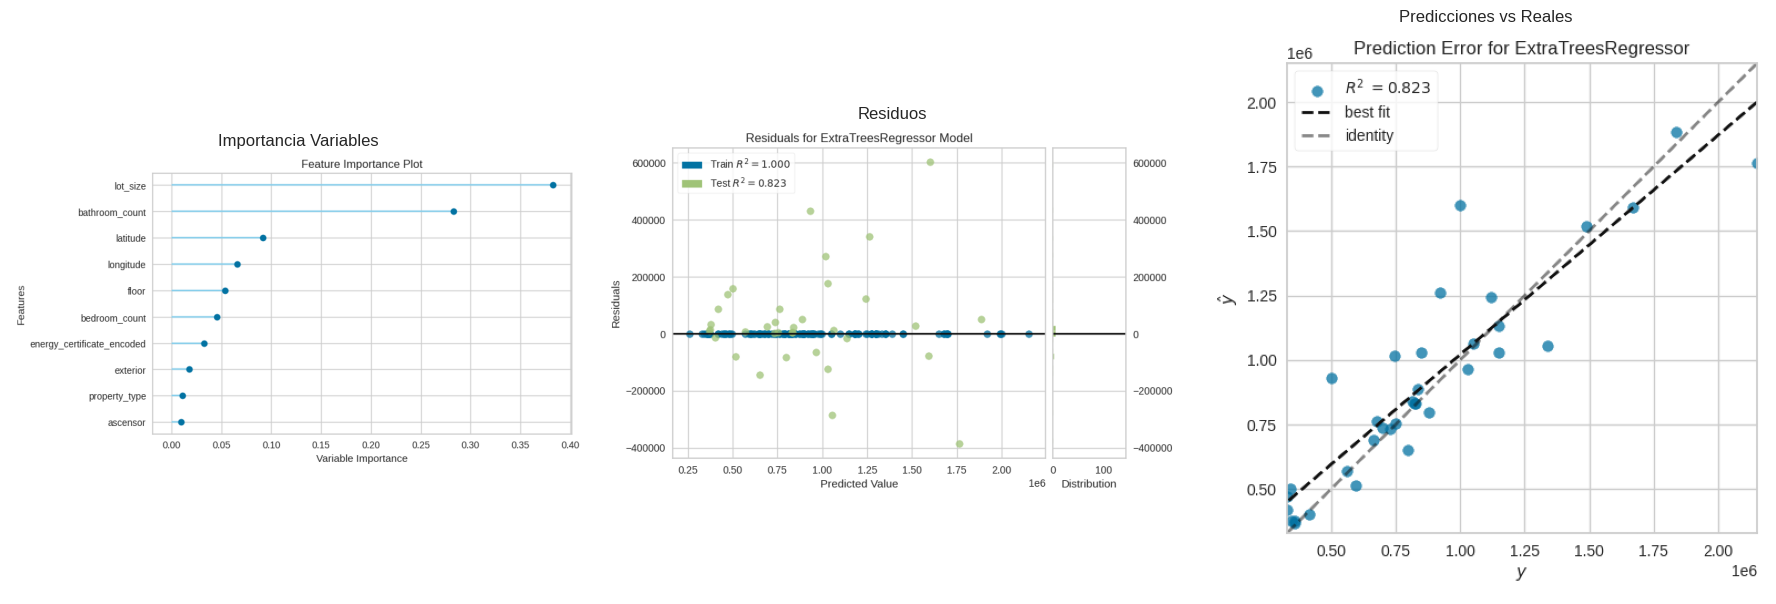

In [33]:
features =[ 'bathroom_count', 'bedroom_count', 'floor',
       'latitude', 'longitude', 'lot_size',
       'property_type', 'neighborhood', 'exterior', 'ascensor','aire_acondicionado', 'energy_certificate_encoded']


df_procesados = analizar_por_barrio(df, neighborhood_dict, features)

## 3.7 Todo


================= Análisis para CHAMBERÍ =================
----- Info preliminar -----
Nuḿero de datos:
365

Precio promedio: 1317.66 k€
Precio mínimo: 250.00 k€
Precio máximo: 3400.00 k€

Promedio de metros cuadrados: 149.39 m²
Promedio de baños: 2.35
Promedio de habitaciones: 2.94

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 18

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 0 valores atípicos
 - bedroom_count: 1 valores atípicos
 - floor: 3 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 6 valores atípicos
 - property_id: 39 valores atípicos
 - exterior: 70 valores atípicos
 - ascensor: 22 valores atípicos
 - altura_techo: 29 valores atípicos
 - dist_metro_m: 0 valores atípicos
 - energy_certificate_encoded: 34 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 231885.59
Error porcentual sobre precio promedio: 19.09%



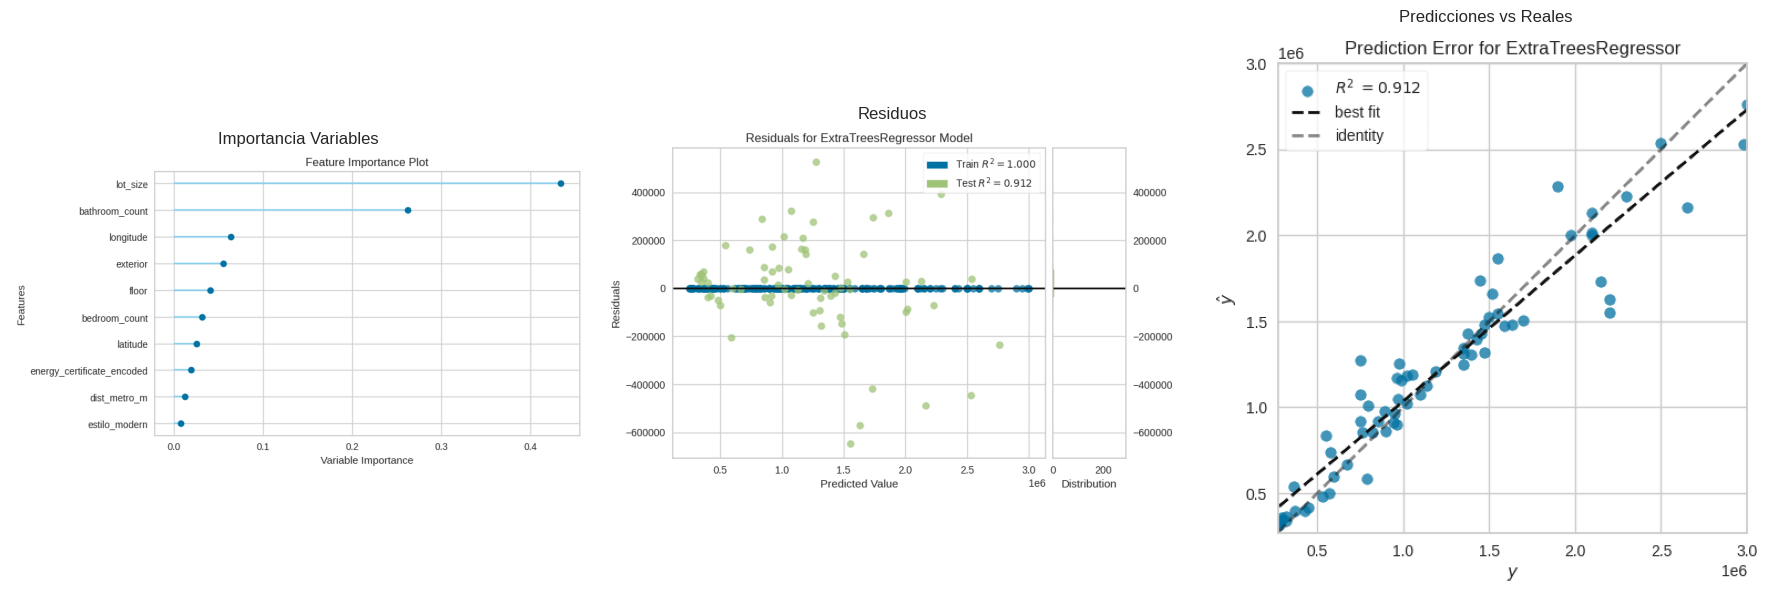


================= Análisis para CENTRO =================
----- Info preliminar -----
Nuḿero de datos:
407

Precio promedio: 1337.19 k€
Precio mínimo: 220.00 k€
Precio máximo: 3450.00 k€

Promedio de metros cuadrados: 228.42 m²
Promedio de baños: 3.01
Promedio de habitaciones: 3.46

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 0

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 15 valores atípicos
 - bedroom_count: 14 valores atípicos
 - floor: 12 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 45 valores atípicos
 - property_id: 45 valores atípicos
 - exterior: 48 valores atípicos
 - ascensor: 52 valores atípicos
 - altura_techo: 21 valores atípicos
 - dist_metro_m: 32 valores atípicos
 - energy_certificate_encoded: 0 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Extra Trees Regressor
RMSE: 297815.75
Error porcentual sobre precio promedio: 22.27%


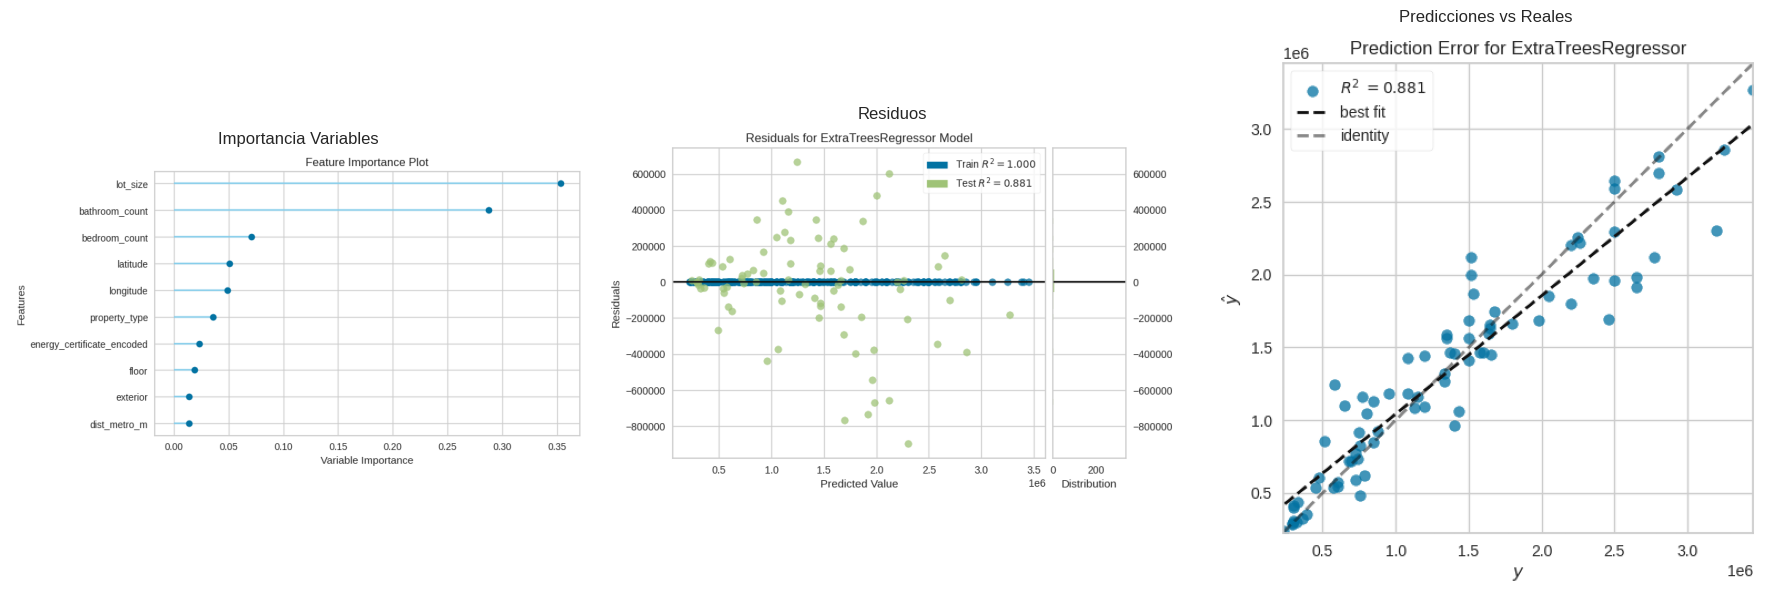


================= Análisis para ARGANZUELA =================
----- Info preliminar -----
Nuḿero de datos:
194

Precio promedio: 499.86 k€
Precio mínimo: 85.40 k€
Precio máximo: 1450.00 k€

Promedio de metros cuadrados: 87.32 m²
Promedio de baños: 1.44
Promedio de habitaciones: 2.45

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 6

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 0 valores atípicos
 - bedroom_count: 0 valores atípicos
 - floor: 0 valores atípicos
 - latitude: 1 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 0 valores atípicos
 - property_id: 22 valores atípicos
 - exterior: 0 valores atípicos
 - ascensor: 22 valores atípicos
 - altura_techo: 4 valores atípicos
 - dist_metro_m: 0 valores atípicos
 - energy_certificate_encoded: 28 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Orthogonal Matching Pursuit
RMSE: 74318.37
Error porcentual sobre precio promedio: 15.63%


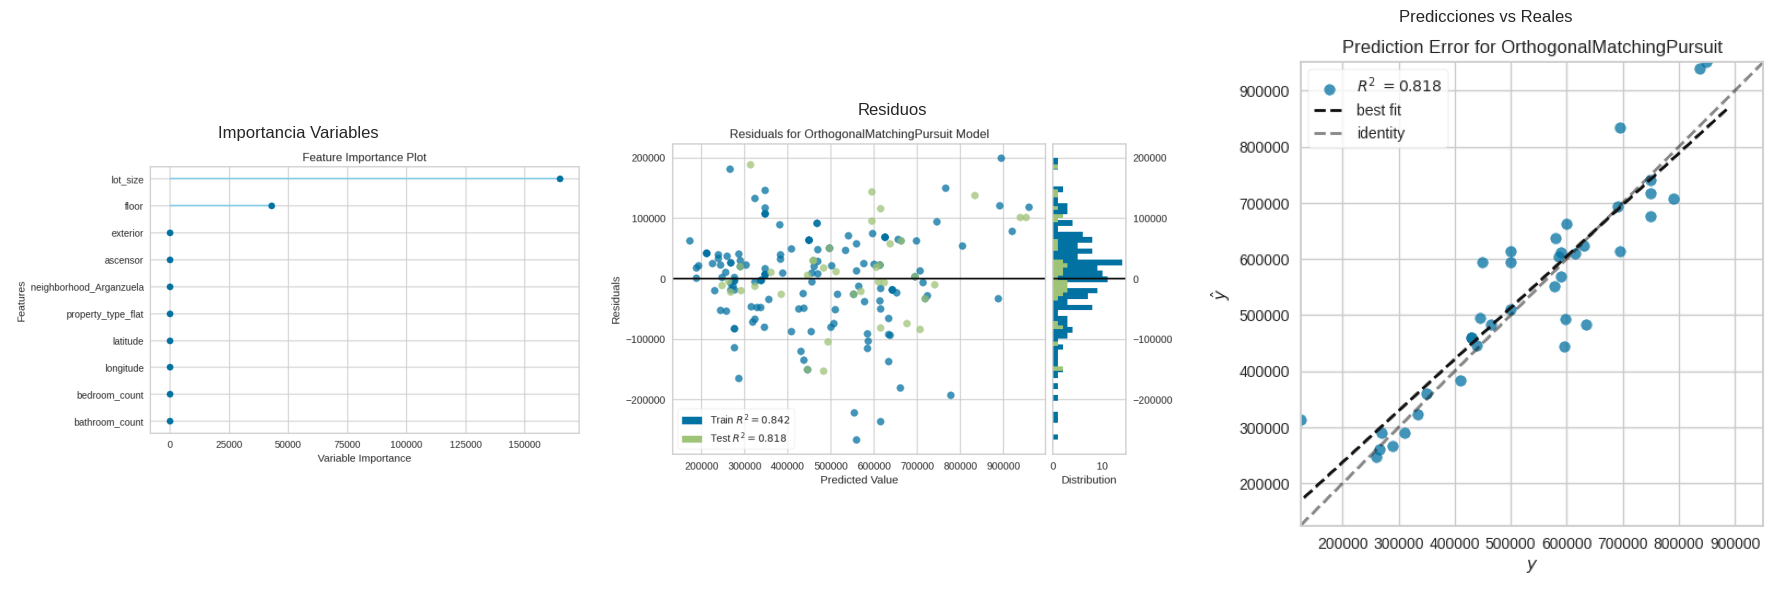


================= Análisis para RETIRO =================
----- Info preliminar -----
Nuḿero de datos:
193

Precio promedio: 1101.52 k€
Precio mínimo: 260.00 k€
Precio máximo: 2950.00 k€

Promedio de metros cuadrados: 129.06 m²
Promedio de baños: 2.07
Promedio de habitaciones: 2.79

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 21

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 7 valores atípicos
 - bedroom_count: 9 valores atípicos
 - floor: 1 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 6 valores atípicos
 - lot_size: 9 valores atípicos
 - property_id: 12 valores atípicos
 - exterior: 0 valores atípicos
 - ascensor: 12 valores atípicos
 - altura_techo: 7 valores atípicos
 - dist_metro_m: 2 valores atípicos
 - energy_certificate_encoded: 29 valores atípicos

-----Evaluando modelos con pycaret------
=== Mejor Modelo ===
Modelo: Gradient Boosting Regressor
RMSE: 188577.57
Error porcentual sobre precio promedio: 20.58%

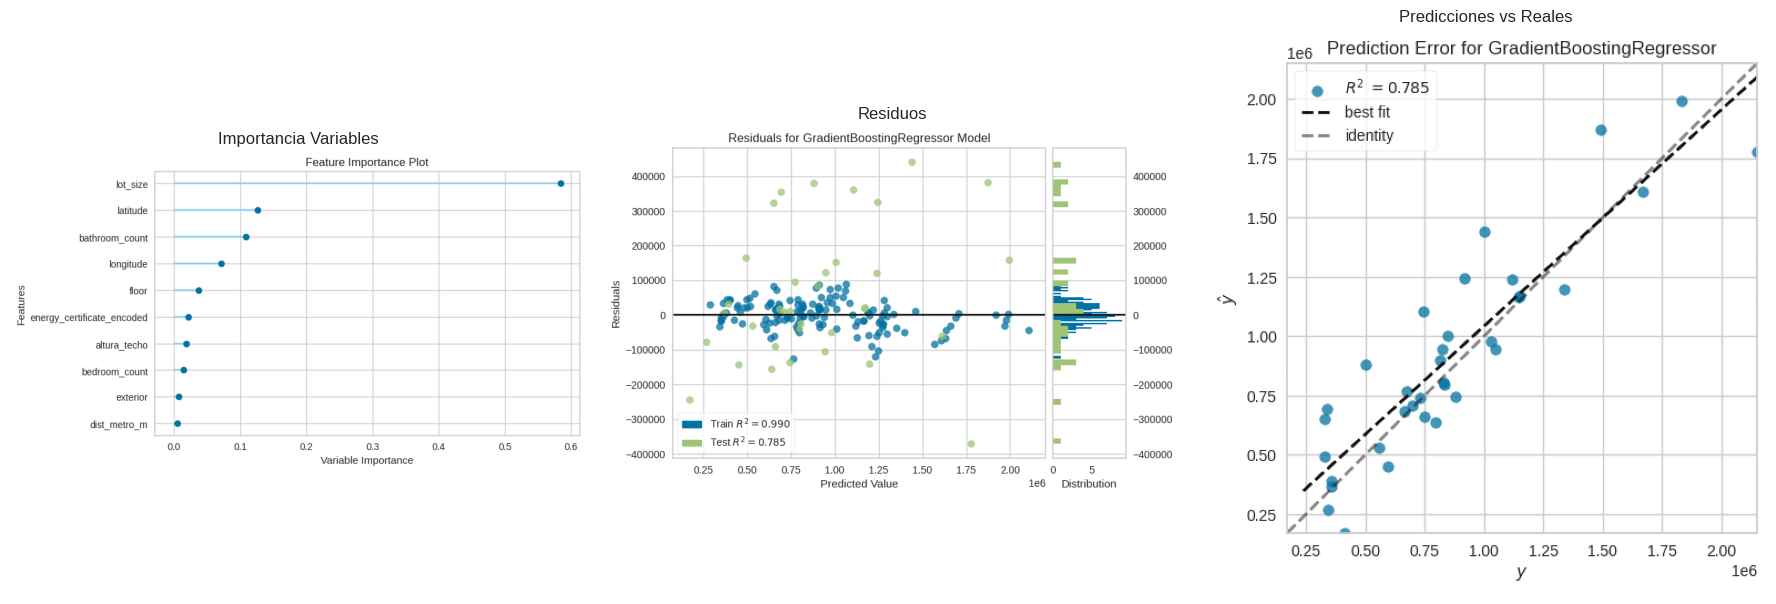

In [ ]:
features =[ 'bathroom_count', 'bedroom_count', 'floor',
       'latitude', 'longitude', 'lot_size',
       'property_type', 'neighborhood', 'exterior', 'ascensor', 'altura_techo',
       'tipo_suelo', 'estilo', 'dist_metro_m', 'energy_certificate_encoded']


df_procesados = analizar_por_barrio(df, neighborhood_dict, features)

# 6. Mejor modelo para cada barrio

In [110]:
df = pd.read_csv('/content/drive/MyDrive/TFM/csv/datos_imagenes_con_aire.csv')

In [111]:
df.columns

Index(['address', 'agency_name', 'bathroom_count', 'bedroom_count',
       'energy_certificate', 'floor', 'latitude', 'longitude', 'lot_size',
       'property_description', 'property_id', 'property_images',
       'property_price', 'property_title', 'property_type', 'neighborhood',
       'exterior', 'ascensor', 'altura_techo', 'tipo_suelo', 'estilo',
       'dist_metro_m', 'aire_acondicionado'],
      dtype='object')

In [112]:
cols_a_borrar = [ 'address', 'agency_name', 'property_description', 'property_images',
                 'property_title']

df = df.drop(columns=cols_a_borrar)

In [113]:
df.dtypes

,0
bathroom_count,int64
bedroom_count,int64
energy_certificate,object
floor,float64
latitude,float64
longitude,float64
lot_size,int64
property_id,int64
property_price,int64
property_type,object


In [114]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# 1️⃣ ————— ELIMINAR OUTLIERS (property_price fuera de 1.5*IQR) —————
def eliminar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_filtrado = df[(df[columna] >= lower) & (df[columna] <= upper)].copy()
    return df_filtrado

df = eliminar_outliers(df, 'property_price')

# 2️⃣ ————— ENCODING ENERGY CERTIFICATE ORDENADO —————
energy_certificate_order = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
energy_certificate_mapping = {cert: i for i, cert in enumerate(energy_certificate_order)}
df['energy_certificate_encoded'] = df['energy_certificate'].str.lower().map(energy_certificate_mapping)
df.drop(columns=['energy_certificate'], inplace=True)

# 3️⃣ ————— TRANSFORMACIONES DE VARIABLES —————

# Convertir categorías a dummies
cat_vars = ['property_type', 'tipo_suelo', 'estilo']
df = pd.get_dummies(df, columns=cat_vars, drop_first=True)

# Variables binarias tipo bool (asegúrate que estén bien en 0 y 1)
binarias = ['exterior', 'ascensor', 'aire_acondicionado']
df[binarias] = df[binarias].fillna(0).astype(int)
print(df.columns)


Index(['bathroom_count', 'bedroom_count', 'floor', 'latitude', 'longitude',
       'lot_size', 'property_id', 'property_price', 'neighborhood', 'exterior',
       'ascensor', 'altura_techo', 'dist_metro_m', 'aire_acondicionado',
       'energy_certificate_encoded', 'property_type_flat',
       'tipo_suelo_parquet', 'tipo_suelo_sin_predicción',
       'tipo_suelo_terrazzo', 'estilo_contemporary', 'estilo_modern',
       'estilo_scandinavian', 'estilo_traditional'],
      dtype='object')


In [118]:

# 4️⃣ ————— DEFINIR X / y, TRAIN / TEST —————
target = 'property_price'
features = ['bathroom_count', 'bedroom_count', 'floor', 'latitude', 'longitude',
       'lot_size', 'neighborhood', 'exterior',
       'ascensor', 'altura_techo','aire_acondicionado',
       'energy_certificate_encoded', 'property_type_flat']

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5️⃣ ————— GRID SEARCH CON EXTRA TREES —————
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 4]
}


model = ExtraTreesRegressor(random_state=42)
grid = GridSearchCV(model, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

# 6️⃣ ————— EVALUACIÓN —————
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
media = y_test.mean()
pct_error = (rmse / media) * 100

# Resultados
print(f"\n✅ Mejor modelo: ExtraTreesRegressor")
print(f"📉 RMSE: {rmse:,.0f} € ({pct_error:.2f}%)")
print(f"📈 R²: {r2:.3f}")


✅ Mejor modelo: ExtraTreesRegressor
📉 RMSE: 241,240 € (22.08%)
📈 R²: 0.887


## clip

In [ ]:
df_final = pd.read_csv('/content/drive/MyDrive/tfm/TFM/datos_con_clip_embeddings.csv')


================= Análisis para CENTRO =================
----- Info preliminar -----
Nuḿero de datos:
434

Precio promedio: 1495.12 k€
Precio mínimo: 220.00 k€
Precio máximo: 4300.00 k€

Promedio de metros cuadrados: 255.10 m²
Promedio de baños: 3.17
Promedio de habitaciones: 3.62

----Outliers Eliminados ----
Filas eliminadas por outliers en 'property_price': 6

Valores atípicos en otras columnas numéricas:
 - bathroom_count: 18 valores atípicos
 - bedroom_count: 11 valores atípicos
 - floor: 12 valores atípicos
 - latitude: 0 valores atípicos
 - longitude: 0 valores atípicos
 - lot_size: 49 valores atípicos
 - exterior: 48 valores atípicos
 - ascensor: 57 valores atípicos
 - dist_metro_m: 28 valores atípicos
 - energy_certificate_encoded: 0 valores atípicos
 - altura_techo: 31 valores atípicos
 - clip_embedding_0: 2 valores atípicos
 - clip_embedding_1: 4 valores atípicos
 - clip_embedding_2: 9 valores atípicos
 - clip_embedding_3: 0 valores atípicos
 - clip_embedding_4: 5 valores a

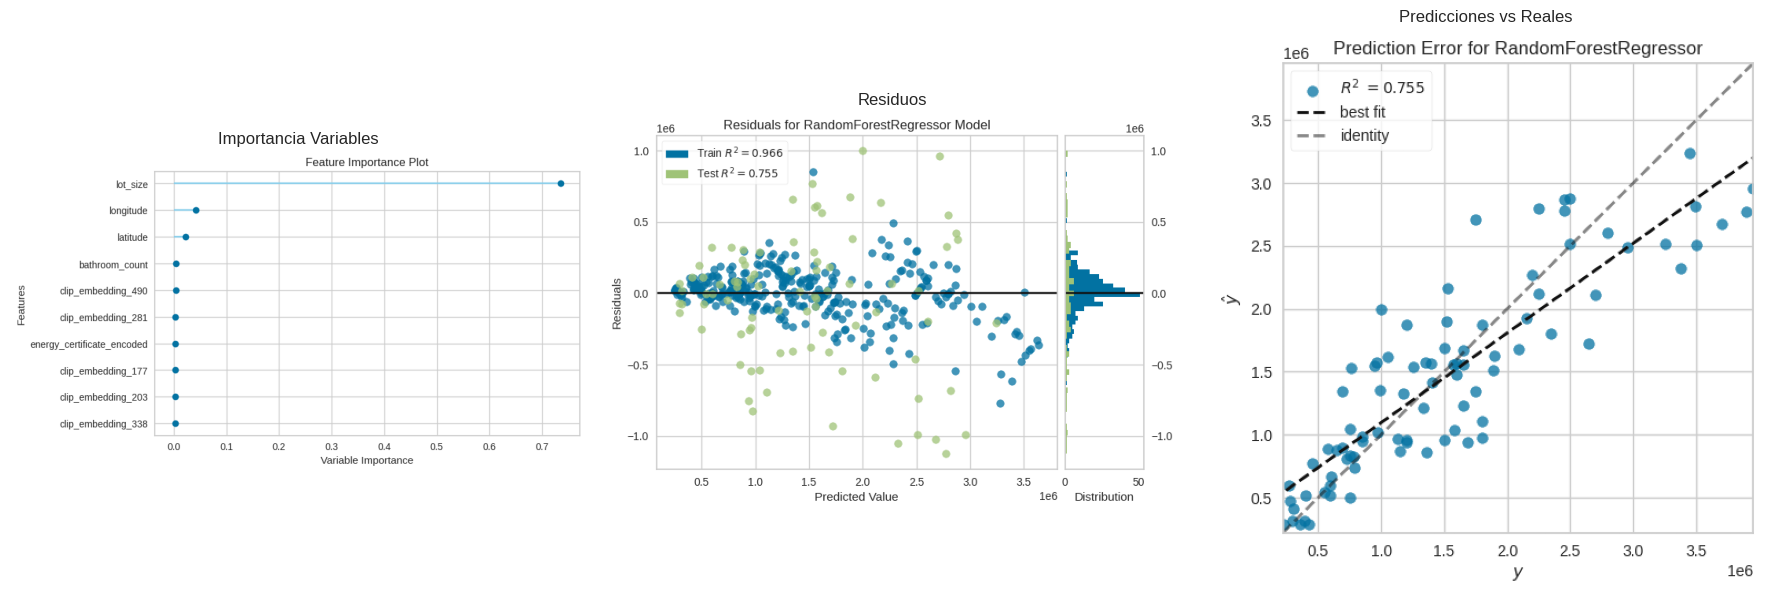

In [ ]:
neighborhood_dict = {

    2: 'Centro'

}

features = ['bathroom_count',
 'bedroom_count',
 'energy_certificate_encoded',
 'floor','property_type_chalet','property_type_flat',
 'lot_size', 'longitude','latitude','altura_techo','clip_embedding_0', 'clip_embedding_1', 'clip_embedding_2', 'clip_embedding_3', 'clip_embedding_4', 'clip_embedding_5', 'clip_embedding_6', 'clip_embedding_7', 'clip_embedding_8', 'clip_embedding_9', 'clip_embedding_10', 'clip_embedding_11', 'clip_embedding_12', 'clip_embedding_13', 'clip_embedding_14', 'clip_embedding_15', 'clip_embedding_16', 'clip_embedding_17', 'clip_embedding_18', 'clip_embedding_19', 'clip_embedding_20', 'clip_embedding_21', 'clip_embedding_22', 'clip_embedding_23', 'clip_embedding_24', 'clip_embedding_25', 'clip_embedding_26', 'clip_embedding_27', 'clip_embedding_28', 'clip_embedding_29', 'clip_embedding_30', 'clip_embedding_31', 'clip_embedding_32', 'clip_embedding_33', 'clip_embedding_34', 'clip_embedding_35', 'clip_embedding_36', 'clip_embedding_37', 'clip_embedding_38', 'clip_embedding_39', 'clip_embedding_40', 'clip_embedding_41', 'clip_embedding_42', 'clip_embedding_43', 'clip_embedding_44', 'clip_embedding_45', 'clip_embedding_46', 'clip_embedding_47', 'clip_embedding_48', 'clip_embedding_49', 'clip_embedding_50', 'clip_embedding_51', 'clip_embedding_52', 'clip_embedding_53', 'clip_embedding_54', 'clip_embedding_55', 'clip_embedding_56', 'clip_embedding_57', 'clip_embedding_58', 'clip_embedding_59', 'clip_embedding_60', 'clip_embedding_61', 'clip_embedding_62', 'clip_embedding_63', 'clip_embedding_64', 'clip_embedding_65', 'clip_embedding_66', 'clip_embedding_67', 'clip_embedding_68', 'clip_embedding_69', 'clip_embedding_70', 'clip_embedding_71', 'clip_embedding_72', 'clip_embedding_73', 'clip_embedding_74', 'clip_embedding_75', 'clip_embedding_76', 'clip_embedding_77', 'clip_embedding_78', 'clip_embedding_79', 'clip_embedding_80', 'clip_embedding_81', 'clip_embedding_82', 'clip_embedding_83', 'clip_embedding_84', 'clip_embedding_85', 'clip_embedding_86', 'clip_embedding_87', 'clip_embedding_88', 'clip_embedding_89', 'clip_embedding_90', 'clip_embedding_91', 'clip_embedding_92', 'clip_embedding_93', 'clip_embedding_94', 'clip_embedding_95', 'clip_embedding_96', 'clip_embedding_97', 'clip_embedding_98', 'clip_embedding_99', 'clip_embedding_100', 'clip_embedding_101', 'clip_embedding_102', 'clip_embedding_103', 'clip_embedding_104', 'clip_embedding_105', 'clip_embedding_106', 'clip_embedding_107', 'clip_embedding_108', 'clip_embedding_109', 'clip_embedding_110', 'clip_embedding_111', 'clip_embedding_112', 'clip_embedding_113', 'clip_embedding_114', 'clip_embedding_115', 'clip_embedding_116', 'clip_embedding_117', 'clip_embedding_118', 'clip_embedding_119', 'clip_embedding_120', 'clip_embedding_121', 'clip_embedding_122', 'clip_embedding_123', 'clip_embedding_124', 'clip_embedding_125', 'clip_embedding_126', 'clip_embedding_127', 'clip_embedding_128', 'clip_embedding_129', 'clip_embedding_130', 'clip_embedding_131', 'clip_embedding_132', 'clip_embedding_133', 'clip_embedding_134', 'clip_embedding_135', 'clip_embedding_136', 'clip_embedding_137', 'clip_embedding_138', 'clip_embedding_139', 'clip_embedding_140', 'clip_embedding_141', 'clip_embedding_142', 'clip_embedding_143', 'clip_embedding_144', 'clip_embedding_145', 'clip_embedding_146', 'clip_embedding_147', 'clip_embedding_148', 'clip_embedding_149', 'clip_embedding_150', 'clip_embedding_151', 'clip_embedding_152', 'clip_embedding_153', 'clip_embedding_154', 'clip_embedding_155', 'clip_embedding_156', 'clip_embedding_157', 'clip_embedding_158', 'clip_embedding_159', 'clip_embedding_160', 'clip_embedding_161', 'clip_embedding_162', 'clip_embedding_163', 'clip_embedding_164', 'clip_embedding_165', 'clip_embedding_166', 'clip_embedding_167', 'clip_embedding_168', 'clip_embedding_169', 'clip_embedding_170', 'clip_embedding_171', 'clip_embedding_172', 'clip_embedding_173', 'clip_embedding_174', 'clip_embedding_175', 'clip_embedding_176', 'clip_embedding_177', 'clip_embedding_178', 'clip_embedding_179', 'clip_embedding_180', 'clip_embedding_181', 'clip_embedding_182', 'clip_embedding_183', 'clip_embedding_184', 'clip_embedding_185', 'clip_embedding_186', 'clip_embedding_187', 'clip_embedding_188', 'clip_embedding_189', 'clip_embedding_190', 'clip_embedding_191', 'clip_embedding_192', 'clip_embedding_193', 'clip_embedding_194', 'clip_embedding_195', 'clip_embedding_196', 'clip_embedding_197', 'clip_embedding_198', 'clip_embedding_199', 'clip_embedding_200', 'clip_embedding_201', 'clip_embedding_202', 'clip_embedding_203', 'clip_embedding_204', 'clip_embedding_205', 'clip_embedding_206', 'clip_embedding_207', 'clip_embedding_208', 'clip_embedding_209', 'clip_embedding_210', 'clip_embedding_211', 'clip_embedding_212', 'clip_embedding_213', 'clip_embedding_214', 'clip_embedding_215', 'clip_embedding_216', 'clip_embedding_217', 'clip_embedding_218', 'clip_embedding_219', 'clip_embedding_220', 'clip_embedding_221', 'clip_embedding_222', 'clip_embedding_223', 'clip_embedding_224', 'clip_embedding_225', 'clip_embedding_226', 'clip_embedding_227', 'clip_embedding_228', 'clip_embedding_229', 'clip_embedding_230', 'clip_embedding_231', 'clip_embedding_232', 'clip_embedding_233', 'clip_embedding_234', 'clip_embedding_235', 'clip_embedding_236', 'clip_embedding_237', 'clip_embedding_238', 'clip_embedding_239', 'clip_embedding_240', 'clip_embedding_241', 'clip_embedding_242', 'clip_embedding_243', 'clip_embedding_244', 'clip_embedding_245', 'clip_embedding_246', 'clip_embedding_247', 'clip_embedding_248', 'clip_embedding_249', 'clip_embedding_250', 'clip_embedding_251', 'clip_embedding_252', 'clip_embedding_253', 'clip_embedding_254', 'clip_embedding_255', 'clip_embedding_256', 'clip_embedding_257', 'clip_embedding_258', 'clip_embedding_259', 'clip_embedding_260', 'clip_embedding_261', 'clip_embedding_262', 'clip_embedding_263', 'clip_embedding_264', 'clip_embedding_265', 'clip_embedding_266', 'clip_embedding_267', 'clip_embedding_268', 'clip_embedding_269', 'clip_embedding_270', 'clip_embedding_271', 'clip_embedding_272', 'clip_embedding_273', 'clip_embedding_274', 'clip_embedding_275', 'clip_embedding_276', 'clip_embedding_277', 'clip_embedding_278', 'clip_embedding_279', 'clip_embedding_280', 'clip_embedding_281', 'clip_embedding_282', 'clip_embedding_283', 'clip_embedding_284', 'clip_embedding_285', 'clip_embedding_286', 'clip_embedding_287', 'clip_embedding_288', 'clip_embedding_289', 'clip_embedding_290', 'clip_embedding_291', 'clip_embedding_292', 'clip_embedding_293', 'clip_embedding_294', 'clip_embedding_295', 'clip_embedding_296', 'clip_embedding_297', 'clip_embedding_298', 'clip_embedding_299', 'clip_embedding_300', 'clip_embedding_301', 'clip_embedding_302', 'clip_embedding_303', 'clip_embedding_304', 'clip_embedding_305', 'clip_embedding_306', 'clip_embedding_307', 'clip_embedding_308', 'clip_embedding_309', 'clip_embedding_310', 'clip_embedding_311', 'clip_embedding_312', 'clip_embedding_313', 'clip_embedding_314', 'clip_embedding_315', 'clip_embedding_316', 'clip_embedding_317', 'clip_embedding_318', 'clip_embedding_319', 'clip_embedding_320', 'clip_embedding_321', 'clip_embedding_322', 'clip_embedding_323', 'clip_embedding_324', 'clip_embedding_325', 'clip_embedding_326', 'clip_embedding_327', 'clip_embedding_328', 'clip_embedding_329', 'clip_embedding_330', 'clip_embedding_331', 'clip_embedding_332', 'clip_embedding_333', 'clip_embedding_334', 'clip_embedding_335', 'clip_embedding_336', 'clip_embedding_337', 'clip_embedding_338', 'clip_embedding_339', 'clip_embedding_340', 'clip_embedding_341', 'clip_embedding_342', 'clip_embedding_343', 'clip_embedding_344', 'clip_embedding_345', 'clip_embedding_346', 'clip_embedding_347', 'clip_embedding_348', 'clip_embedding_349', 'clip_embedding_350', 'clip_embedding_351', 'clip_embedding_352', 'clip_embedding_353', 'clip_embedding_354', 'clip_embedding_355', 'clip_embedding_356', 'clip_embedding_357', 'clip_embedding_358', 'clip_embedding_359', 'clip_embedding_360', 'clip_embedding_361', 'clip_embedding_362', 'clip_embedding_363', 'clip_embedding_364', 'clip_embedding_365', 'clip_embedding_366', 'clip_embedding_367', 'clip_embedding_368', 'clip_embedding_369', 'clip_embedding_370', 'clip_embedding_371', 'clip_embedding_372', 'clip_embedding_373', 'clip_embedding_374', 'clip_embedding_375', 'clip_embedding_376', 'clip_embedding_377', 'clip_embedding_378', 'clip_embedding_379', 'clip_embedding_380', 'clip_embedding_381', 'clip_embedding_382', 'clip_embedding_383', 'clip_embedding_384', 'clip_embedding_385', 'clip_embedding_386', 'clip_embedding_387', 'clip_embedding_388', 'clip_embedding_389', 'clip_embedding_390', 'clip_embedding_391', 'clip_embedding_392', 'clip_embedding_393', 'clip_embedding_394', 'clip_embedding_395', 'clip_embedding_396', 'clip_embedding_397', 'clip_embedding_398', 'clip_embedding_399', 'clip_embedding_400', 'clip_embedding_401', 'clip_embedding_402', 'clip_embedding_403', 'clip_embedding_404', 'clip_embedding_405', 'clip_embedding_406', 'clip_embedding_407', 'clip_embedding_408', 'clip_embedding_409', 'clip_embedding_410', 'clip_embedding_411', 'clip_embedding_412', 'clip_embedding_413', 'clip_embedding_414', 'clip_embedding_415', 'clip_embedding_416', 'clip_embedding_417', 'clip_embedding_418', 'clip_embedding_419', 'clip_embedding_420', 'clip_embedding_421', 'clip_embedding_422', 'clip_embedding_423', 'clip_embedding_424', 'clip_embedding_425', 'clip_embedding_426', 'clip_embedding_427', 'clip_embedding_428', 'clip_embedding_429', 'clip_embedding_430', 'clip_embedding_431', 'clip_embedding_432', 'clip_embedding_433', 'clip_embedding_434', 'clip_embedding_435', 'clip_embedding_436', 'clip_embedding_437', 'clip_embedding_438', 'clip_embedding_439', 'clip_embedding_440', 'clip_embedding_441', 'clip_embedding_442', 'clip_embedding_443', 'clip_embedding_444', 'clip_embedding_445', 'clip_embedding_446', 'clip_embedding_447', 'clip_embedding_448', 'clip_embedding_449', 'clip_embedding_450', 'clip_embedding_451', 'clip_embedding_452', 'clip_embedding_453', 'clip_embedding_454', 'clip_embedding_455', 'clip_embedding_456', 'clip_embedding_457', 'clip_embedding_458', 'clip_embedding_459', 'clip_embedding_460', 'clip_embedding_461', 'clip_embedding_462', 'clip_embedding_463', 'clip_embedding_464', 'clip_embedding_465', 'clip_embedding_466', 'clip_embedding_467', 'clip_embedding_468', 'clip_embedding_469', 'clip_embedding_470', 'clip_embedding_471', 'clip_embedding_472', 'clip_embedding_473', 'clip_embedding_474', 'clip_embedding_475', 'clip_embedding_476', 'clip_embedding_477', 'clip_embedding_478', 'clip_embedding_479', 'clip_embedding_480', 'clip_embedding_481', 'clip_embedding_482', 'clip_embedding_483', 'clip_embedding_484', 'clip_embedding_485', 'clip_embedding_486', 'clip_embedding_487', 'clip_embedding_488', 'clip_embedding_489', 'clip_embedding_490', 'clip_embedding_491', 'clip_embedding_492', 'clip_embedding_493', 'clip_embedding_494', 'clip_embedding_495', 'clip_embedding_496', 'clip_embedding_497', 'clip_embedding_498', 'clip_embedding_499', 'clip_embedding_500', 'clip_embedding_501', 'clip_embedding_502', 'clip_embedding_503', 'clip_embedding_504', 'clip_embedding_505', 'clip_embedding_506', 'clip_embedding_507', 'clip_embedding_508', 'clip_embedding_509', 'clip_embedding_510', 'clip_embedding_511']

df_procesados = analizar_por_barrio(df_final, neighborhood_dict, features)

# 5. Visualizaciones

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/drive/MyDrive/TFM/csv/datos_imagenes_con_aire.csv')
df.columns


Index(['address', 'agency_name', 'bathroom_count', 'bedroom_count',
       'energy_certificate', 'floor', 'latitude', 'longitude', 'lot_size',
       'property_description', 'property_id', 'property_images',
       'property_price', 'property_title', 'property_type', 'neighborhood',
       'exterior', 'ascensor', 'altura_techo', 'tipo_suelo', 'estilo',
       'dist_metro_m', 'aire_acondicionado'],
      dtype='object')

In [12]:
MODERN_PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
sns.set_style("whitegrid", {'grid.color': '#f0f0f0'})
sns.set_palette(MODERN_PALETTE)

barrio_labels = {
    1: 'Chamberí',
    2: 'Centro',
    3: 'Arganzuela',
    4: 'Retiro'
}
df['barrio'] = df['neighborhood'].map(barrio_labels)


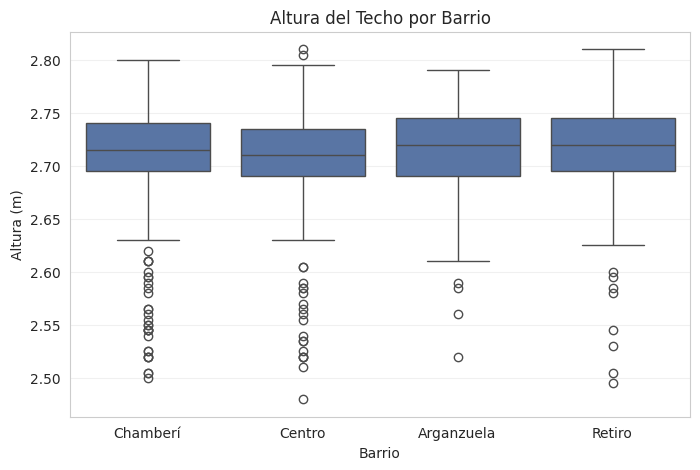

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='barrio', y='altura_techo')
plt.title('Altura del Techo por Barrio')
plt.xlabel('Barrio')
plt.ylabel('Altura (m)')
plt.show()


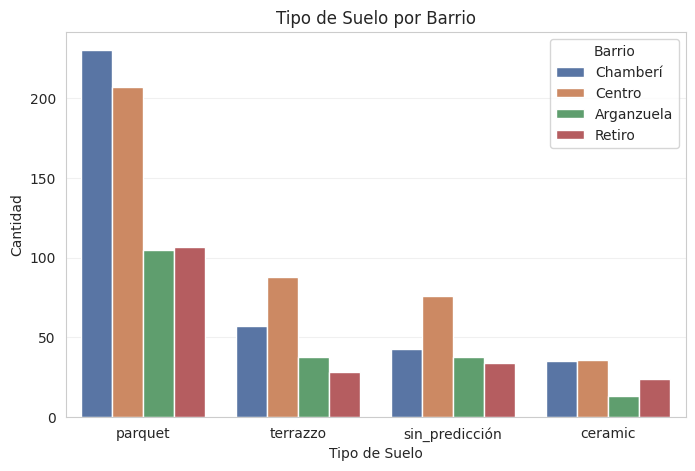

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='tipo_suelo', hue='barrio')
plt.title('Tipo de Suelo por Barrio')
plt.xlabel('Tipo de Suelo')
plt.ylabel('Cantidad')
plt.legend(title='Barrio')
plt.show()


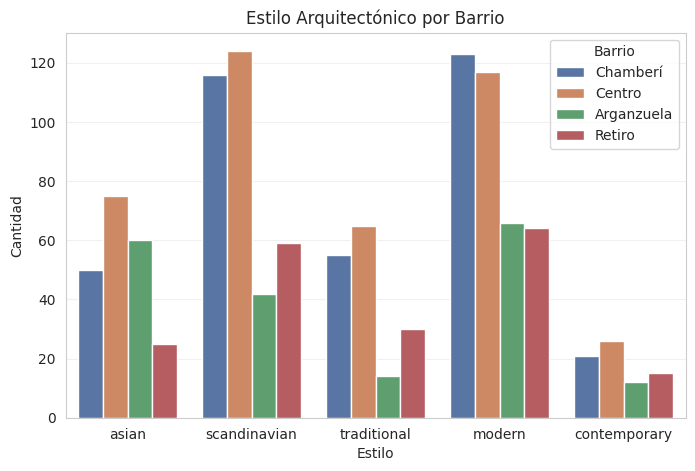

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='estilo', hue='barrio')
plt.title('Estilo Arquitectónico por Barrio')
plt.xlabel('Estilo')
plt.ylabel('Cantidad')
plt.legend(title='Barrio')
plt.show()


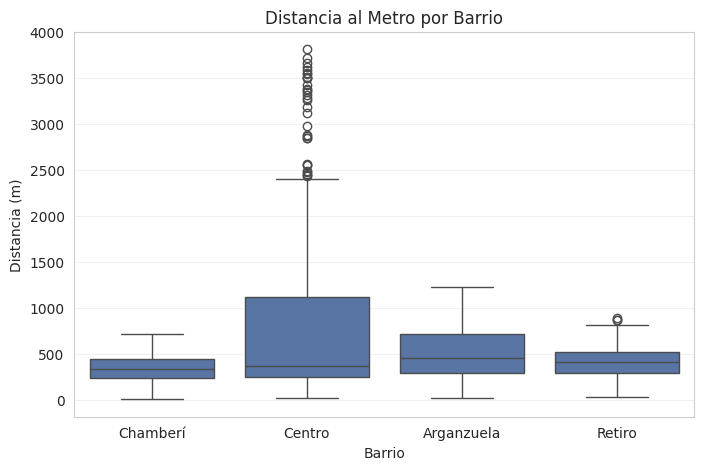

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='barrio', y='dist_metro_m')
plt.title('Distancia al Metro por Barrio')
plt.xlabel('Barrio')
plt.ylabel('Distancia (m)')
plt.show()


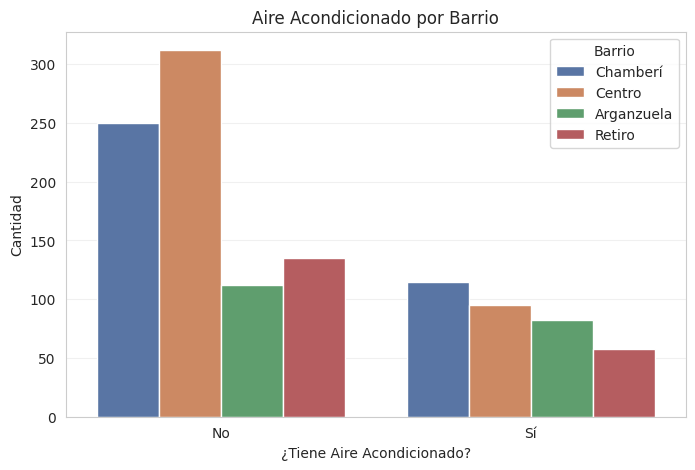

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='aire_acondicionado', hue='barrio')
plt.title('Aire Acondicionado por Barrio')
plt.xlabel('¿Tiene Aire Acondicionado?')
plt.ylabel('Cantidad')
plt.xticks([0, 1], ['No', 'Sí'])
plt.legend(title='Barrio')
plt.show()


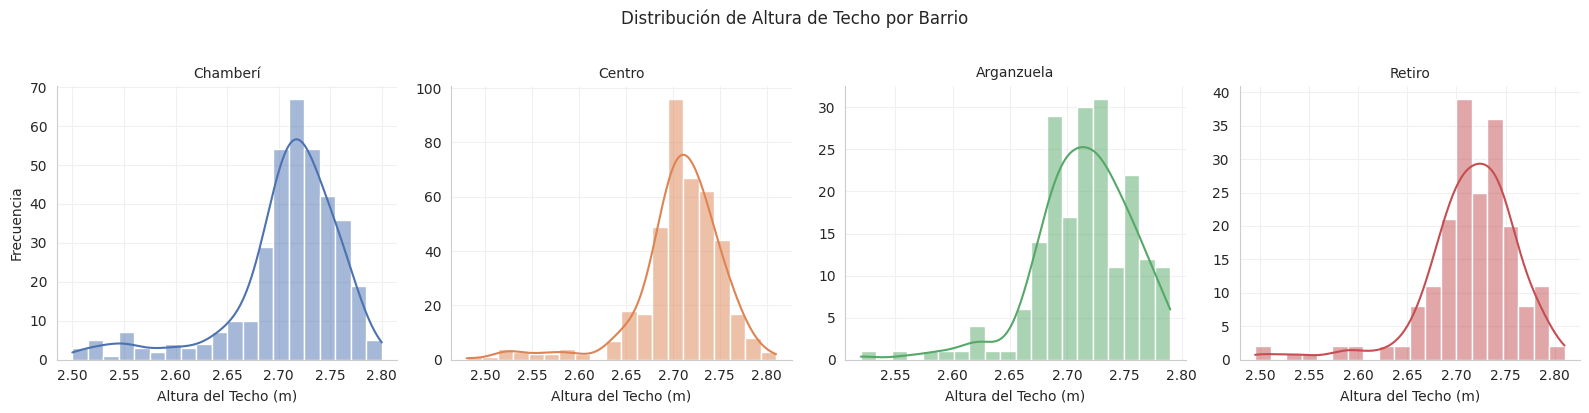

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un diccionario de colores por barrio
color_map = {
    'Chamberí': MODERN_PALETTE[0],
    'Centro': MODERN_PALETTE[1],
    'Arganzuela': MODERN_PALETTE[2],
    'Retiro': MODERN_PALETTE[3]
}

# Función para graficar con color según barrio
def hist_with_color(data, color=None, **kwargs):
    barrio = data['barrio'].iloc[0]
    sns.histplot(data=data, x='altura_techo', bins=20, kde=True, color=color_map[barrio], **kwargs)

# Crear FacetGrid
g = sns.FacetGrid(df, col='barrio', col_wrap=4, height=4, sharex=False, sharey=False)
g.map_dataframe(hist_with_color)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Altura del Techo (m)", "Frecuencia")
g.fig.suptitle('Distribución de Altura de Techo por Barrio', y=1.02)
plt.tight_layout()
plt.show()


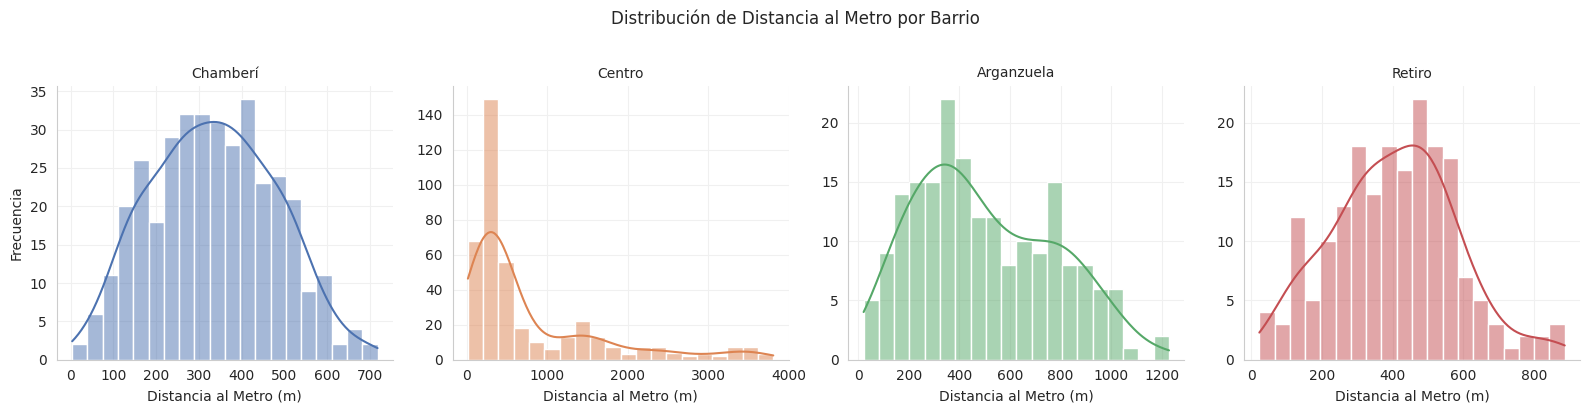

In [20]:
# Función adaptada para dist_metro_m
def hist_dist_metro(data, color=None, **kwargs):
    barrio = data['barrio'].iloc[0]
    sns.histplot(data=data, x='dist_metro_m', bins=20, kde=True, color=color_map[barrio], **kwargs)

# Crear FacetGrid
g = sns.FacetGrid(df, col='barrio', col_wrap=4, height=4, sharex=False, sharey=False)
g.map_dataframe(hist_dist_metro)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Distancia al Metro (m)", "Frecuencia")
g.fig.suptitle('Distribución de Distancia al Metro por Barrio', y=1.02)
plt.tight_layout()
plt.show()


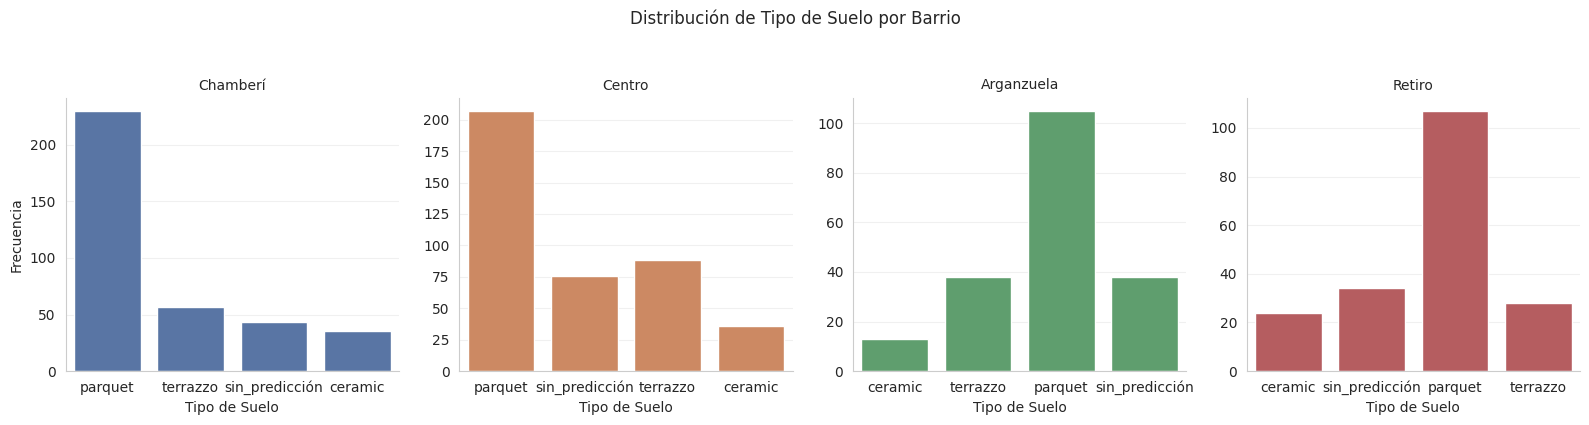

In [21]:
# Función para contar valores de tipo_suelo con color por barrio
def count_tipo_suelo(data, color=None, **kwargs):
    barrio = data['barrio'].iloc[0]
    sns.countplot(data=data, x='tipo_suelo', color=color_map[barrio], **kwargs)

# Crear FacetGrid
g = sns.FacetGrid(df, col='barrio', col_wrap=4, height=4, sharex=False, sharey=False)
g.map_dataframe(count_tipo_suelo)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Tipo de Suelo", "Frecuencia")
g.fig.suptitle('Distribución de Tipo de Suelo por Barrio', y=1.05)
plt.tight_layout()
plt.show()


# PRUEBA RMSE OPTIMO FEATURES OPCIONALES

In [ ]:
import pandas as pd
from itertools import combinations
from pycaret.regression import *

# Agregar las funciones que ya tienes
def info_inicial(df):
    # Mapeo de neighborhoods
    neighborhood_map = {
        1: 'Chamberí',
        2: 'Centro',
        3: 'Arganzuela',
        4: 'Retiro'
    }

    df['neighborhood'] = df['neighborhood'].map(neighborhood_map)

    # Estadísticas de property_price
    precio_promedio = df['property_price'].mean()
    precio_min = df['property_price'].min()
    precio_max = df['property_price'].max()

    # Estadísticas de otros campos
    metros_promedio = df['lot_size'].mean()
    banos_promedio = df['bathroom_count'].mean()
    habitaciones_promedio = df['bedroom_count'].mean()

    # Mostrar resultados
    print(f"Nuḿero de datos:\n{len(df)}")
    print(f"\nPrecio promedio: {precio_promedio/1000:.2f} k€")
    print(f"Precio mínimo: {precio_min/1000:.2f} k€")
    print(f"Precio máximo: {precio_max/1000:.2f} k€")
    print(f"\nPromedio de metros cuadrados: {metros_promedio:.2f} m²")
    print(f"Promedio de baños: {banos_promedio:.2f}")
    print(f"Promedio de habitaciones: {habitaciones_promedio:.2f}")

    return df  # Devuelve el df actualizado con los nombres de barrios

def eliminar_outliers(df):
    df_original = df.copy()
    numeric_cols = df.select_dtypes(include='number').columns

    # Outliers in property_price with IQR
    Q1 = df['property_price'].quantile(0.25)
    Q3 = df['property_price'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filtering and resetting index
    df = df[(df['property_price'] >= lower_bound) & (df['property_price'] <= upper_bound)].reset_index(drop=True)
    filas_eliminadas = df_original.shape[0] - df.shape[0]

    print(f"\n----Outliers Eliminados ----")
    print(f"Filas eliminadas por outliers en 'property_price': {filas_eliminadas}")

    # Contar outliers in other numeric columns and ensure index alignment
    print("\nValores atípicos en otras columnas numéricas:")
    for col in numeric_cols:
        if col != 'property_price':
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            # Create the boolean mask and explicitly reindex it to match df's index
            outliers_mask = ((df[col] < lower_bound) | (df[col] > upper_bound)).reindex(df.index)
            outliers = df[outliers_mask].shape[0]
            print(f" - {col}: {outliers} valores atípicos")

    return df

def mejor_modelo_pycaret(df, features):
    print('\n-----Evaluando modelos con pycaret------')

    df_pycaret = df[features + ['property_price']]

    setup(
        data=df_pycaret,
        target='property_price',
        session_id=42,
        train_size=0.8,
        normalize=True,
        verbose=False
    )

    # Añade verbose=False para evitar salida innecesaria
    best_model_pycaret = compare_models(sort='RMSE', verbose=False)

    # Usamos pull para capturar la tabla sin mostrarla
    resultados = pull();  # El punto y coma evita que Jupyter la muestre

    mejor_fila = resultados.loc[resultados['RMSE'].idxmin()]
    nombre_modelo = mejor_fila['Model']
    rmse = mejor_fila['RMSE']

    precio_medio = df['property_price'].mean()
    error_porcentual = (rmse / precio_medio) * 100

    print("=== Mejor Modelo ===")
    print(f"Modelo: {nombre_modelo}")
    print(f"RMSE: {rmse:.2f}")
    print(f"Error porcentual sobre precio promedio: {error_porcentual:.2f}%")

    return best_model_pycaret

def visualizaciones_modelo_simple(df, modelo):
    """
    Versión simplificada que usa plot_model directamente sin guardar archivos
    """
    print("\nVisualizaciones del modelo:")

    try:
        from pycaret.regression import plot_model

        print("  - Generando gráfico de importancia de variables...")
        plot_model(modelo, plot='feature', display_format='streamlit')

        print("  - Generando gráfico de residuos...")
        plot_model(modelo, plot='residuals', display_format='streamlit')

        print("  - Generando gráfico de predicciones vs reales...")
        plot_model(modelo, plot='error', display_format='streamlit')

    except Exception as e:
        print(f"  ⚠️ Error en visualizaciones: {str(e)}")
        print("  Las visualizaciones no son críticas, continuando...")

df_final = pd.read_csv('/content/drive/MyDrive/CEU SAN PABLO/TFM/datos_metrotechosuelo.csv')

neighborhood_dict = {
    1: 'Chamberí',
    2: 'Centro',
    3: 'Arganzuela',
    4: 'Retiro'
}

# Variables base que siempre se incluyen
base_features = ['bathroom_count', 'bedroom_count', 'energy_certificate_encoded',
                'floor', 'lot_size', 'longitude', 'latitude']

# Variables opcionales para optimizar
optional_features = ['tipo_suelo', 'altura_techo', 'dist_metro_m']

def probar_combinaciones_variables(df_barrio, base_features, optional_features):
    """
    Prueba todas las combinaciones posibles de variables opcionales
    y devuelve la combinación que da el mejor RMSE
    """
    mejores_features = base_features.copy()
    mejor_rmse = float('inf')
    mejor_modelo = None
    resultados = []

    print("Probando diferentes combinaciones de variables:")

    # Generar todas las combinaciones posibles (incluyendo conjunto vacío)
    for r in range(len(optional_features) + 1):
        for combo in combinations(optional_features, r):
            features_actuales = base_features + list(combo)

            try:
                combo_str = ", ".join(combo) if combo else "Solo variables base"

                # Capturar solo la primera línea del print para evitar el error de formato
                import io
                import sys
                old_stdout = sys.stdout
                sys.stdout = captured_output = io.StringIO()

                try:
                    resultado_modelo = mejor_modelo_pycaret(df_barrio, features_actuales)
                finally:
                    sys.stdout = old_stdout

                # Obtener RMSE y modelo
                rmse_actual, modelo_actual = obtener_rmse_y_modelo(resultado_modelo)

                print(f"  - {combo_str}: RMSE = {rmse_actual:.4f}")

                resultados.append({
                    'combinacion': combo,
                    'features': features_actuales,
                    'rmse': rmse_actual,
                    'modelo': modelo_actual
                })

                # Actualizar mejor combinación si es necesario
                if rmse_actual < mejor_rmse:
                    mejor_rmse = rmse_actual
                    mejores_features = features_actuales.copy()
                    mejor_modelo = modelo_actual

            except Exception as e:
                combo_str = ", ".join(combo) if combo else "Solo variables base"
                print(f"  - {combo_str}: Error - {str(e)}")

    return mejores_features, mejor_rmse, mejor_modelo, resultados

def obtener_rmse_y_modelo(resultado_modelo):
    """
    Función auxiliar para obtener el RMSE y el modelo desde el resultado de mejor_modelo_pycaret
    Tu función devuelve directamente el mejor modelo, y usa pull() para obtener las métricas
    """
    try:
        from pycaret.regression import pull

        # Tu función mejor_modelo_pycaret devuelve directamente el modelo
        modelo = resultado_modelo

        # Obtener las métricas usando pull() (como en tu función original)
        resultados = pull()

        # Obtener el RMSE del mejor modelo (primera fila, ya que compare_models ordena por RMSE)
        rmse = resultados.iloc[0]['RMSE']

        return rmse, modelo

    except Exception as e:
        print(f"Error obteniendo RMSE: {e}")
        return float('inf'), None

# Crear una lista para almacenar los DataFrames procesados de cada barrio
df_procesados = []
resultados_por_barrio = {}

for codigo, nombre in neighborhood_dict.items():
    print(f"\n================= Análisis para {nombre.upper()} =================")

    # 1. Subset del dataset original
    print('----- Info preliminar -----')
    df_barrio = df_final[df_final['neighborhood'] == nombre].copy()

    # 2. Info inicial
    info_inicial(df_barrio)

    # 3. Eliminar outliers
    df_barrio = eliminar_outliers(df_barrio)

    # 4. Selección automática de mejores variables
    print('\n----- Optimización de variables -----')
    mejores_features, mejor_rmse, mejor_modelo, todos_resultados = probar_combinaciones_variables(
        df_barrio, base_features, optional_features
    )

    # Mostrar resultados de la optimización
    variables_seleccionadas = [var for var in mejores_features if var in optional_features]
    variables_excluidas = [var for var in optional_features if var not in mejores_features]

    print(f"\n✓ Mejor combinación para {nombre}:")
    print(f"  - RMSE: {mejor_rmse:.4f}")
    print(f"  - Variables adicionales incluidas: {variables_seleccionadas if variables_seleccionadas else 'Ninguna'}")
    print(f"  - Variables adicionales excluidas: {variables_excluidas if variables_excluidas else 'Ninguna'}")

    # Guardar resultados para análisis posterior
    resultados_por_barrio[nombre] = {
        'mejores_features': mejores_features,
        'mejor_rmse': mejor_rmse,
        'mejor_modelo': mejor_modelo,
        'todos_resultados': todos_resultados,
        'variables_adicionales_incluidas': variables_seleccionadas,
        'variables_adicionales_excluidas': variables_excluidas
    }

    # Agregar el DataFrame procesado a la lista
    df_procesados.append(df_barrio)

    # 5. Visualizaciones con el mejor modelo (versión simplificada)
    if mejor_modelo is not None:
        print('\n----- Visualizaciones del mejor modelo -----')
        try:
            visualizaciones_modelo_simple(df_barrio, mejor_modelo)
        except Exception as e:
            print(f"⚠️ Error en visualizaciones: {str(e)}")
            print("Continuando con el siguiente barrio...")
    else:
        print('\n⚠️  No se pudo generar modelo válido para visualizaciones')

# Combinar todos los DataFrames procesados en uno solo
df_final_procesado = pd.concat(df_procesados, ignore_index=True)

# Resumen final de optimización
print("\n" + "="*80)
print("RESUMEN FINAL DE OPTIMIZACIÓN POR BARRIO")
print("="*80)

for nombre, resultados in resultados_por_barrio.items():
    print(f"\n{nombre}:")
    print(f"  - RMSE final: {resultados['mejor_rmse']:.4f}")
    print(f"  - Variables adicionales utilizadas: {resultados['variables_adicionales_incluidas'] if resultados['variables_adicionales_incluidas'] else 'Ninguna'}")

    # Mostrar mejora vs modelo base si disponible
    modelo_base_result = next((r for r in resultados['todos_resultados'] if len(r['combinacion']) == 0), None)
    if modelo_base_result and len(resultados['variables_adicionales_incluidas']) > 0:
        mejora = modelo_base_result['rmse'] - resultados['mejor_rmse']
        mejora_pct = (mejora / modelo_base_result['rmse']) * 100
        print(f"  - Mejora vs modelo base: {mejora:.4f} ({mejora_pct:.2f}%)")

# Análisis global de variables más útiles
print(f"\n{'-'*50}")
print("ANÁLISIS GLOBAL DE VARIABLES:")
print(f"{'-'*50}")

conteo_variables = {}
for var in optional_features:
    conteo_variables[var] = sum(1 for r in resultados_por_barrio.values() if var in r['variables_adicionales_incluidas'])

for var, count in conteo_variables.items():
    porcentaje = (count / len(neighborhood_dict)) * 100
    print(f"- {var}: Útil en {count}/{len(neighborhood_dict)} barrios ({porcentaje:.1f}%)")

ImportError: cannot import name '_center' from 'numpy.core._multiarray_umath' (/usr/local/lib/python3.11/dist-packages/numpy/core/_multiarray_umath.cpython-311-x86_64-linux-gnu.so)

# GRAFICAS

In [ ]:
!pip install shap

Generating SHAP summary plot...


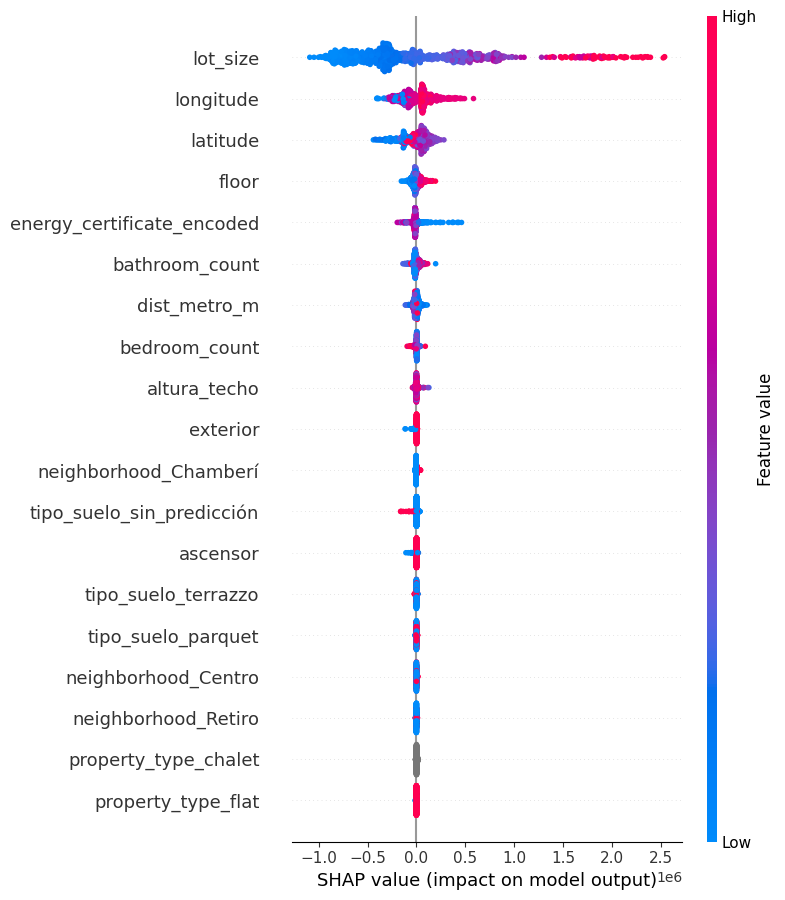

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap

df_shap = pd.read_csv('/content/drive/MyDrive/CEU SAN PABLO/TFM/datos_metrotechosuelo.csv')

# Prepare features and target variable
features = [
    'bathroom_count', 'bedroom_count', 'energy_certificate_encoded', 'floor', 'latitude',
    'longitude', 'neighborhood', 'exterior', 'ascensor', 'lot_size',
    'property_type_chalet', 'property_type_flat','tipo_suelo','altura_techo','dist_metro_m'
]

# Ensure categorical features are handled correctly
# For RandomForestRegressor, one-hot encoding is a common approach.
X = df_shap[features].copy()
X = pd.get_dummies(X, columns=['neighborhood', 'tipo_suelo'], drop_first=True) # One-hot encode both 'neighborhood' and 'tipo_suelo'

y = df_shap['property_price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a RandomForestRegressor model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# SHAP TreeExplainer
# Use the trained model and training data to create the explainer and calculate SHAP values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)

# Generate the SHAP summary plot
print("Generating SHAP summary plot...")
shap.summary_plot(shap_values, X_train)

In [ ]:
!pip install --upgrade pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 124.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 110.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.1.4
    Uninstalling pandas-2.1.4:
      Successfully uninstalled pandas-2.1.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
matplotlib 3.7.5 requires numpy<2,>=1.20, but you have numpy 2.3.1 which is incompatible.
scipy 1.11.4 requires numpy<1.28.0,>=1.21.6, but you have numpy 2.3.1 which is incompatible.
sktime 0.26.0 requi

In [ ]:
!pip uninstall -y pandas numpy pycaret
!pip install pycaret

Found existing installation: pandas 2.3.0
Uninstalling pandas-2.3.0:
  Successfully uninstalled pandas-2.3.0
Found existing installation: numpy 2.3.1
Uninstalling numpy-2.3.1:
  Successfully uninstalled numpy-2.3.1
Found existing installation: pycaret 3.3.2
Uninstalling pycaret-3.3.2:
  Successfully uninstalled pycaret-3.3.2
  Using cached pycaret-3.3.2-py3-none-any.whl.metadata (17 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pandas-2.1.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
Using cached pycaret-3.3.2-py3-none-any.whl (486 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
Using cached pandas-2.1.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following depend